# Интерпретация

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.inspection import partial_dependence, PartialDependenceDisplay, permutation_importance
from sklearn.metrics import mean_squared_error, r2_score
import lime
import lime.lime_tabular
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.feature_selection import VarianceThreshold
import time
from IPython.display import display
from PyALE import ale
from sklearn.metrics.pairwise import pairwise_distances
import shap
from sklearn.compose import ColumnTransformer

warnings.filterwarnings("ignore")
%config InlineBackend.figure_format = 'retina'


### Загрузка и подготовка данных


Вам будет предоставлен датасет, посвященный продаже недвижимости. Ваша задача - построить интерпретацию для этого датасета. В нем достаточно много различных признаков, поэтому вы можете предварительно отфильтровать их, когда будете строить графики. Оставляйте достаточно признаков, чтобы ваши модели оставались точными..

In [2]:
data_path = r"C:\Users\annap\VSCode\python\nikolskaya\spbu_ml_2026\additional_materials\datasets\hw_interpretation\data.csv"
data = pd.read_csv(data_path, sep=',')

print(f"Размер датасета: {data.shape}")
print(f"\nПервые строки:")
data.head()


Размер датасета: (29905, 83)

Первые строки:


,region_name_cat,district_cat,corpus_cat,developer_cat,agreement_date,floor,square,rooms_4,location_logs_count_mean,location_depth,...,location_public_transport_platform_w_mean_distance,location_water_w_mean_distance,location_university_w_mean_distance,location_leisure_w_mean_distance,location_pop_shop_cnt,price_target,hc_name_cat,interior_cat,class_cat,stage_cat
0,Город,45,538,18,2012-08-10,3.0,62.23,2,22.550466,13.0,...,0.910028,0.782675,-999.000000,0.820073,16.0,28417.424671,50,49786.0,27353,7983
1,Пригород,48,432,63,2013-05-19,11.0,22.52,студия,22.581858,13.0,...,0.902510,0.902673,-999.000000,0.990908,18.0,16728.215463,293,49786.0,97865,70661
2,Город,44,2372,126,2012-12-12,3.0,38.17,1,20.191250,13.0,...,0.851637,-999.000000,-999.000000,0.945618,7.0,18311.834458,284,49786.0,97865,70661
3,Город,14,1053,121,2012-12-10,10.0,57.48,2,23.286900,13.0,...,0.913797,1.028386,0.300026,0.828147,5.0,25171.489968,325,0.0,97865,12638
4,Город,63,2426,69,2012-02-12,3.0,41.43,1,20.599150,13.0,...,1.051049,-999.000000,-999.000000,0.991506,4.0,27324.795343,182,49786.0,97865,70661


## Задание 1. 1 балл
Сделайте 2 версии данных - с нормализацией признаков и без.
Обучите 6 моделей:
- линейную регрессию (LinearRegression) на двух вариантах данных
- Lasso регрессию (Lasso) на двух вариантах данных
- градиентный бустинг (GradientBoostingRegressor) на двух вариантах данных. Ограничьте глубину до 5.

Выведите MSE,RMSE и MAPE моделей. Какая функция больше подходит? Почему?

Зафиксируйте выводы. Какие модели чувствительны к масштабу признаков, а какие почти инвариантны? Почему это важно для анализа признаков?

In [3]:
df = pd.read_csv(data_path)
df = df.loc[:, ~df.columns.duplicated()]

y = df["price_target"]
X = df.drop(columns=["price_target"]).select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_train.columns, index=X_test.index)

def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return mse, np.sqrt(mse), mean_absolute_percentage_error(y_true, y_pred)

rows = []

for name, model in [
    ("LR", LinearRegression()),
    ("Lasso", Lasso(alpha=0.1, max_iter=10000)),
    ("GBR", GradientBoostingRegressor(max_depth=5, random_state=42)),
]:
    m1 = model.__class__(**model.get_params())
    m1.fit(X_train, y_train)
    rows.append([name, "no_scale", *metrics(y_test, m1.predict(X_test))])

    m2 = model.__class__(**model.get_params())
    m2.fit(X_train_scaled, y_train)
    rows.append([name, "scale", *metrics(y_test, m2.predict(X_test_scaled))])

res_df = pd.DataFrame(rows, columns=["model", "data", "MSE", "RMSE", "MAPE"])
res_df

,model,data,MSE,RMSE,MAPE
0,LR,no_scale,2.013695e+07,4487.421443,0.100442
1,LR,scale,2.013695e+07,4487.421443,0.100442
2,Lasso,no_scale,2.124985e+07,4609.756445,0.104347
3,Lasso,scale,2.099881e+07,4582.445757,0.103520
4,GBR,no_scale,3.722582e+06,1929.399364,0.041696
5,GBR,scale,3.749072e+06,1936.251999,0.041740


## Задание 1.1(*) 1 балл
Сравните модели, построенные с помощью разных видов нормализации (MinMax, Standart). Отличается ли важность признаков?

In [4]:
scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

lasso_std = Lasso(alpha=0.1, max_iter=10000)
lasso_std.fit(X_train_std, y_train)

lasso_mm = Lasso(alpha=0.1, max_iter=10000)
lasso_mm.fit(X_train_mm, y_train)

coef_df = pd.DataFrame(
    {"StandardScaler": lasso_std.coef_, "MinMaxScaler": lasso_mm.coef_},
    index=X_train.columns
)
coef_df["abs_std"] = coef_df["StandardScaler"].abs()
coef_df["abs_minmax"] = coef_df["MinMaxScaler"].abs()
coef_df = coef_df.sort_values("abs_std", ascending=False)
coef_df

,StandardScaler,MinMaxScaler,abs_std,abs_minmax
location_std_levels_mean,-22183.511074,-30284.215001,22183.511074,30284.215001
location_shop_other_w_mean_distance,21993.430620,29214.837984,21993.430620,29214.837984
location_hds_ratio_mean_mean,3881.749586,28478.546858,3881.749586,28478.546858
location_amenity_restaurant_w_mean_distance,3689.006239,18777.204568,3689.006239,18777.204568
location_public_transport_platform_w_mean_distance,3441.648851,-0.000000,3441.648851,0.000000
...,...,...,...,...
location_office_w_mean_distance,28.695707,-87.338587,28.695707,87.338587
location_water_cnt,18.958781,102.550612,18.958781,102.550612
location_depth,0.000000,0.000000,0.000000,0.000000
location_depth.1,0.000000,0.000000,0.000000,0.000000


## Задание 2. 1 балл
Выберите 1 признак для анализа (можно категориальный, с не менее чем 5 уровнями, или дискретизируйте непрерывный). 
Используйте линейную регрессию и бустинг после применения MinMaxScaler. Что будет с моделями, если признаки выйдут из диапазона?
Постройте графики ICE и PDP для интерпретации исходных данных, а также искусственно добавив несколько выбросов, выходящих за оригинальные интервалы. 

Задание 2.1 (*) 1 балл: проанализируйте также еще один признак

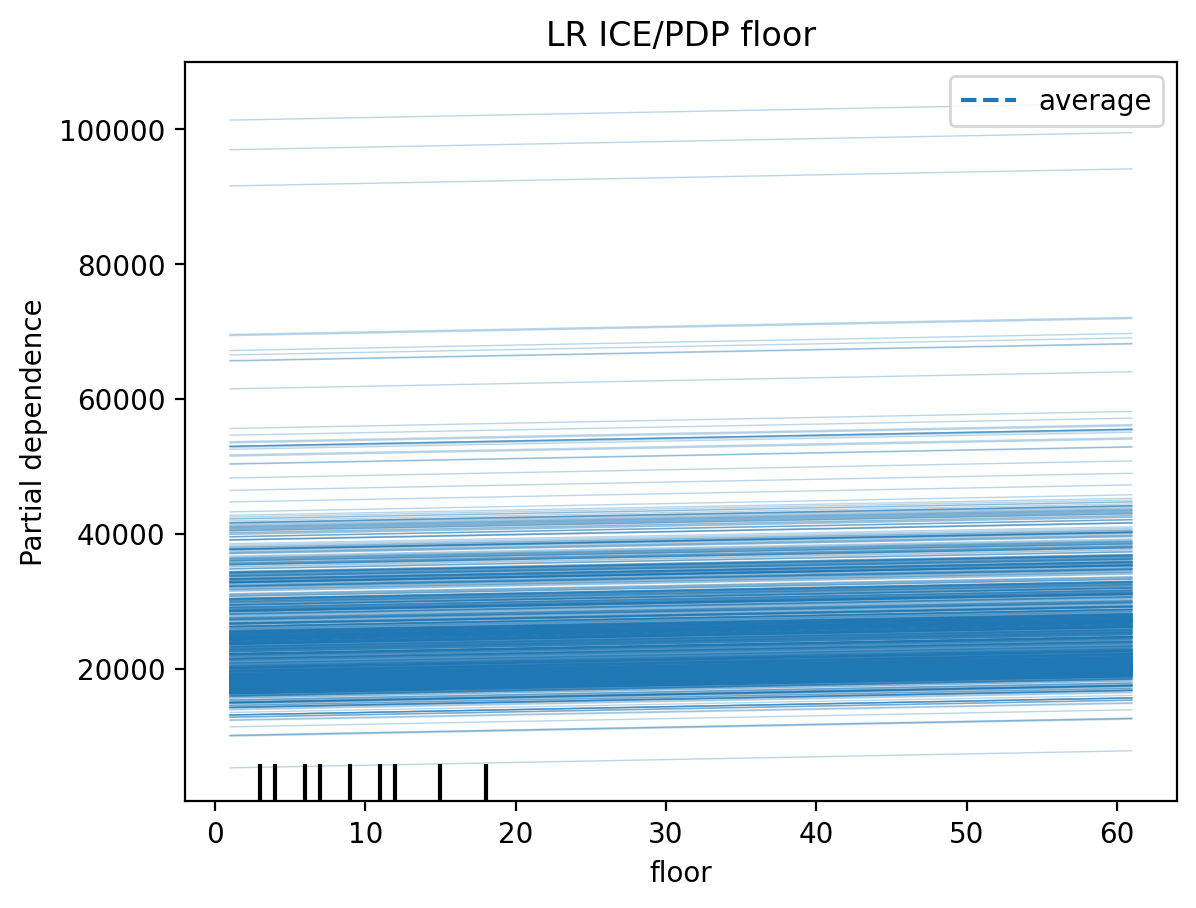

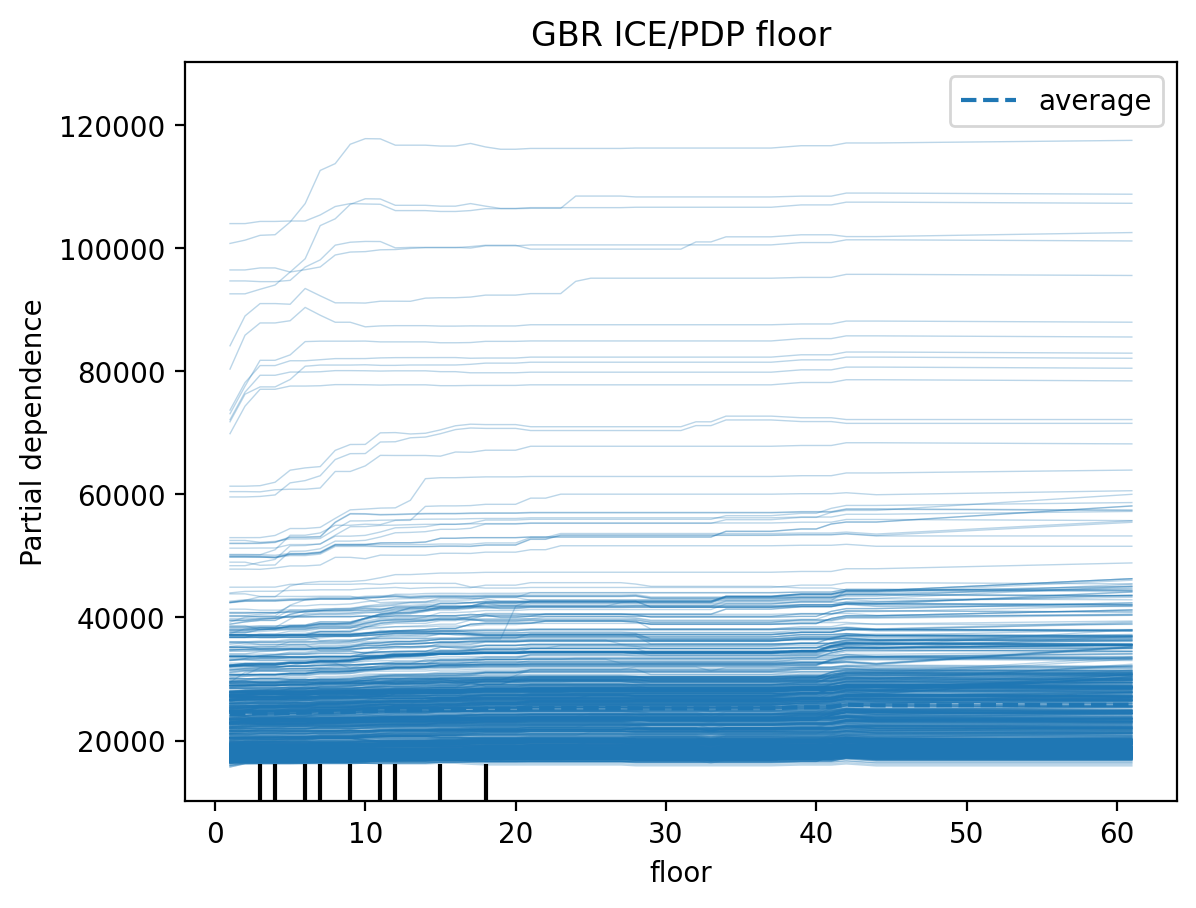

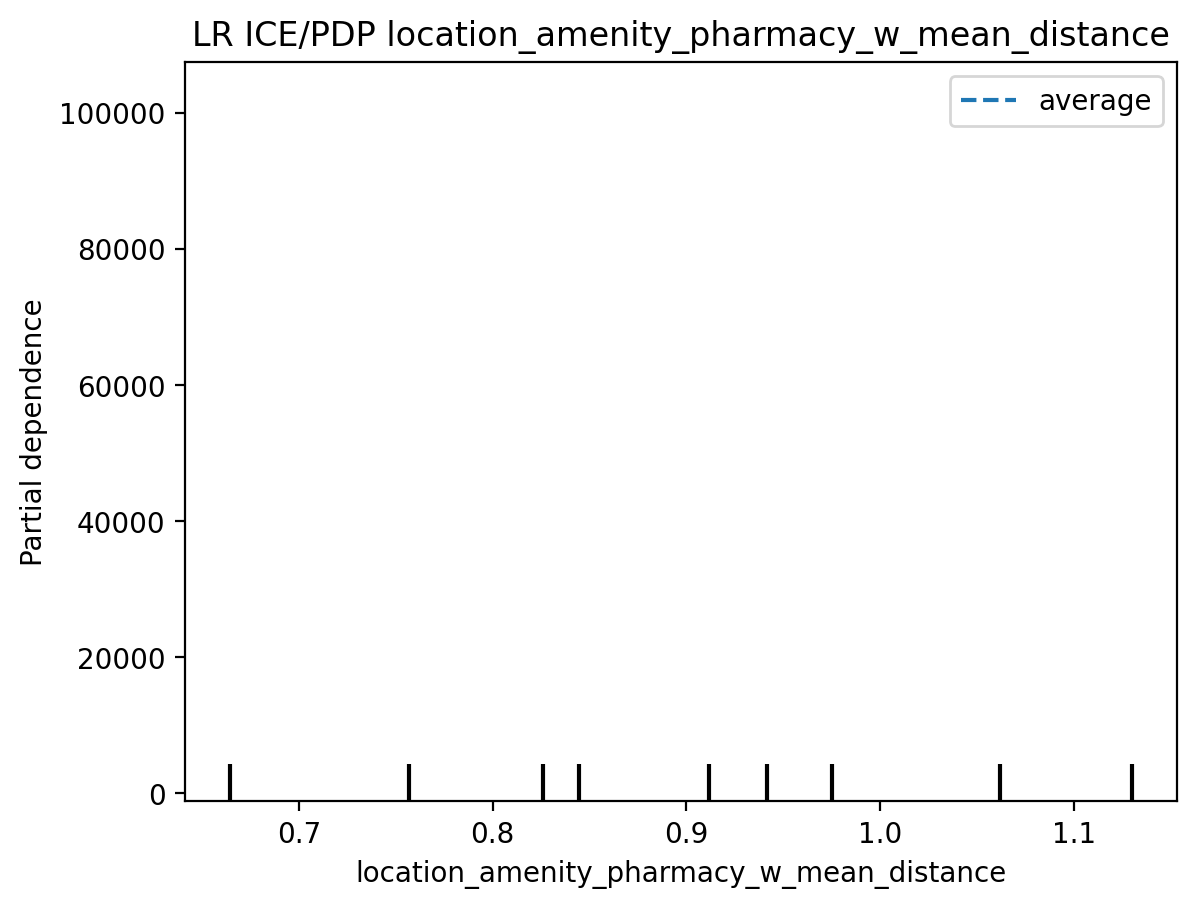

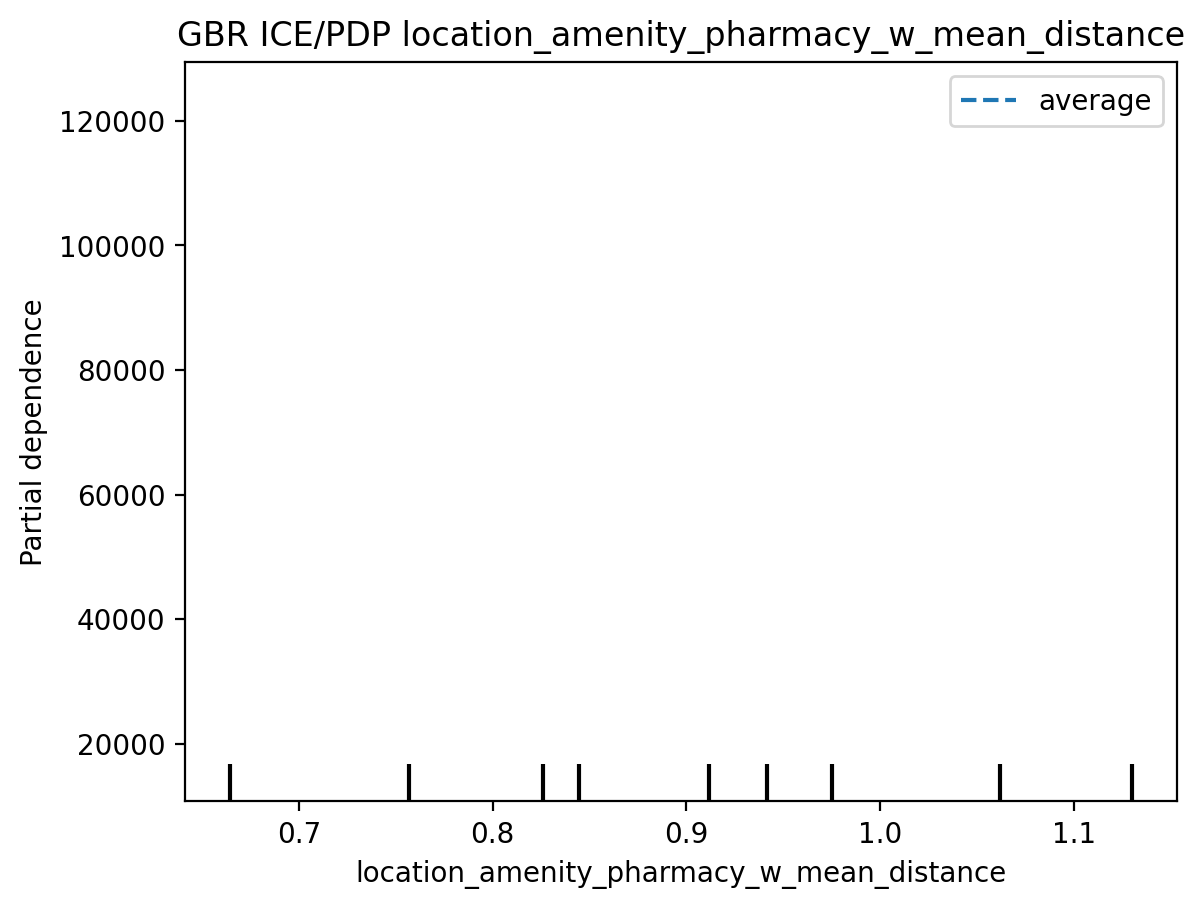

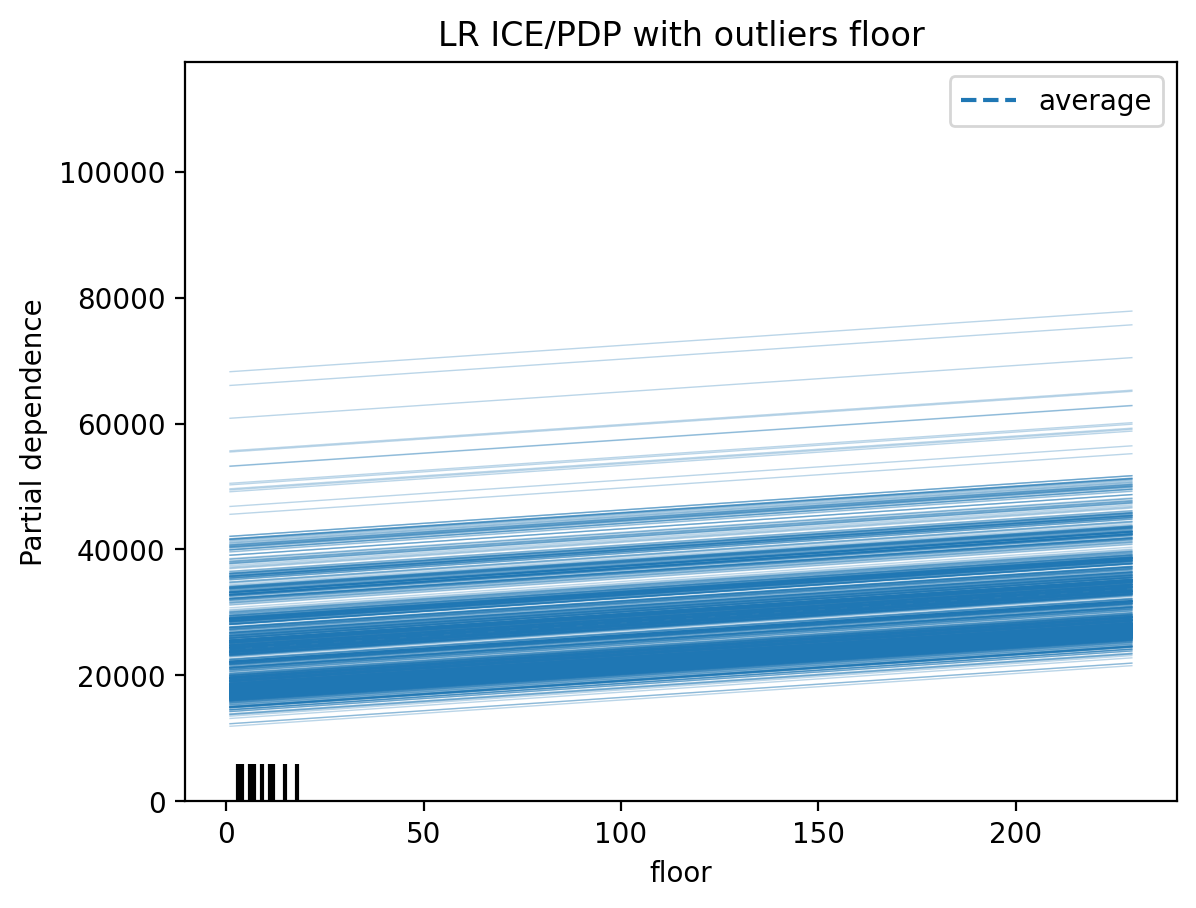

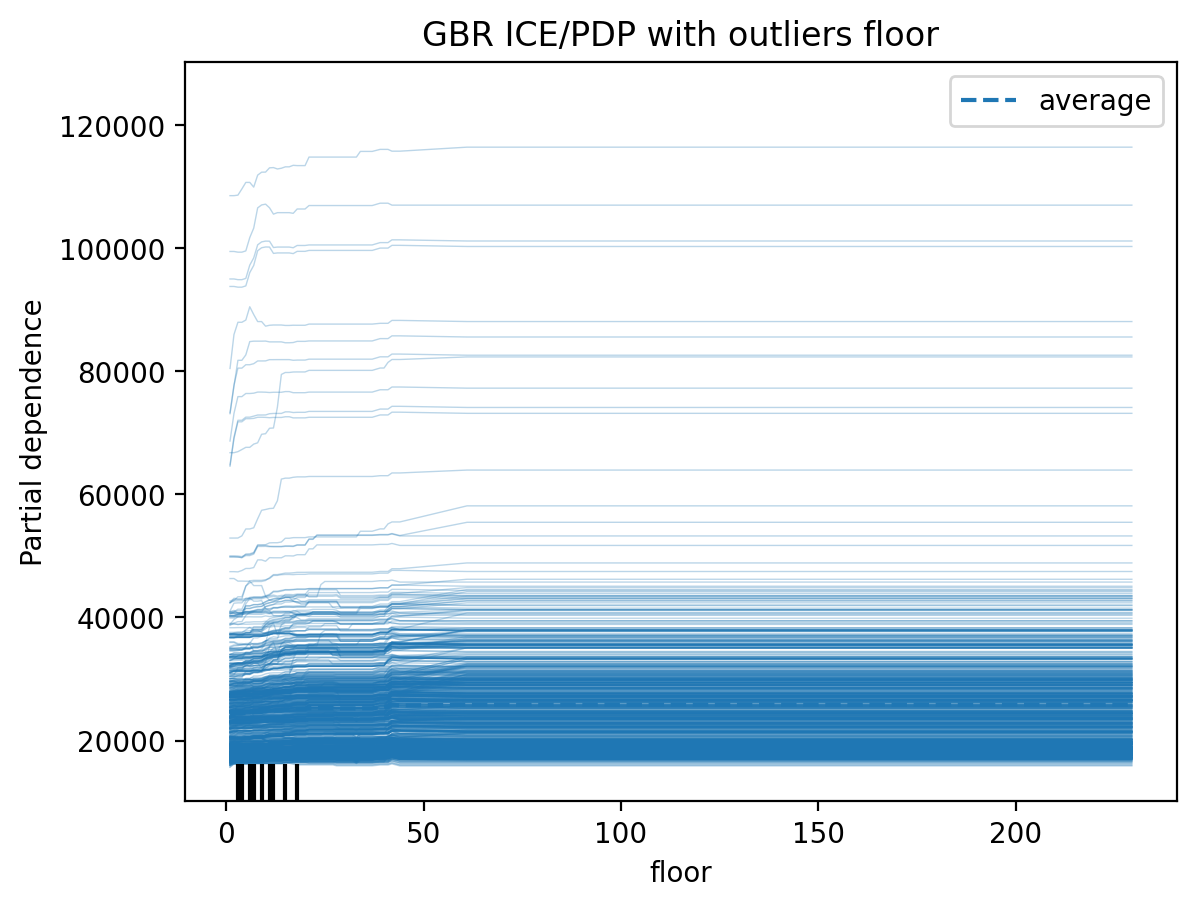

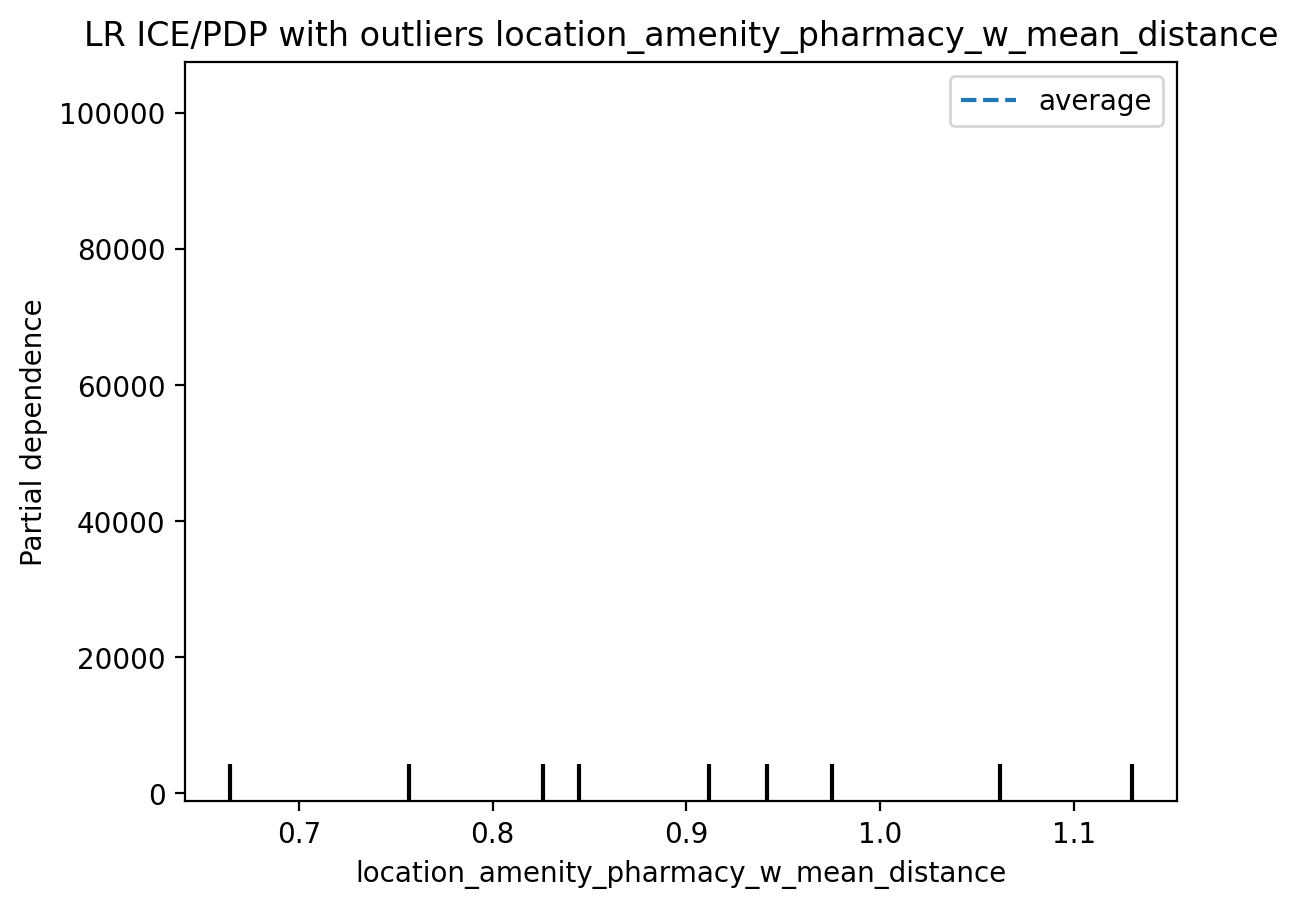

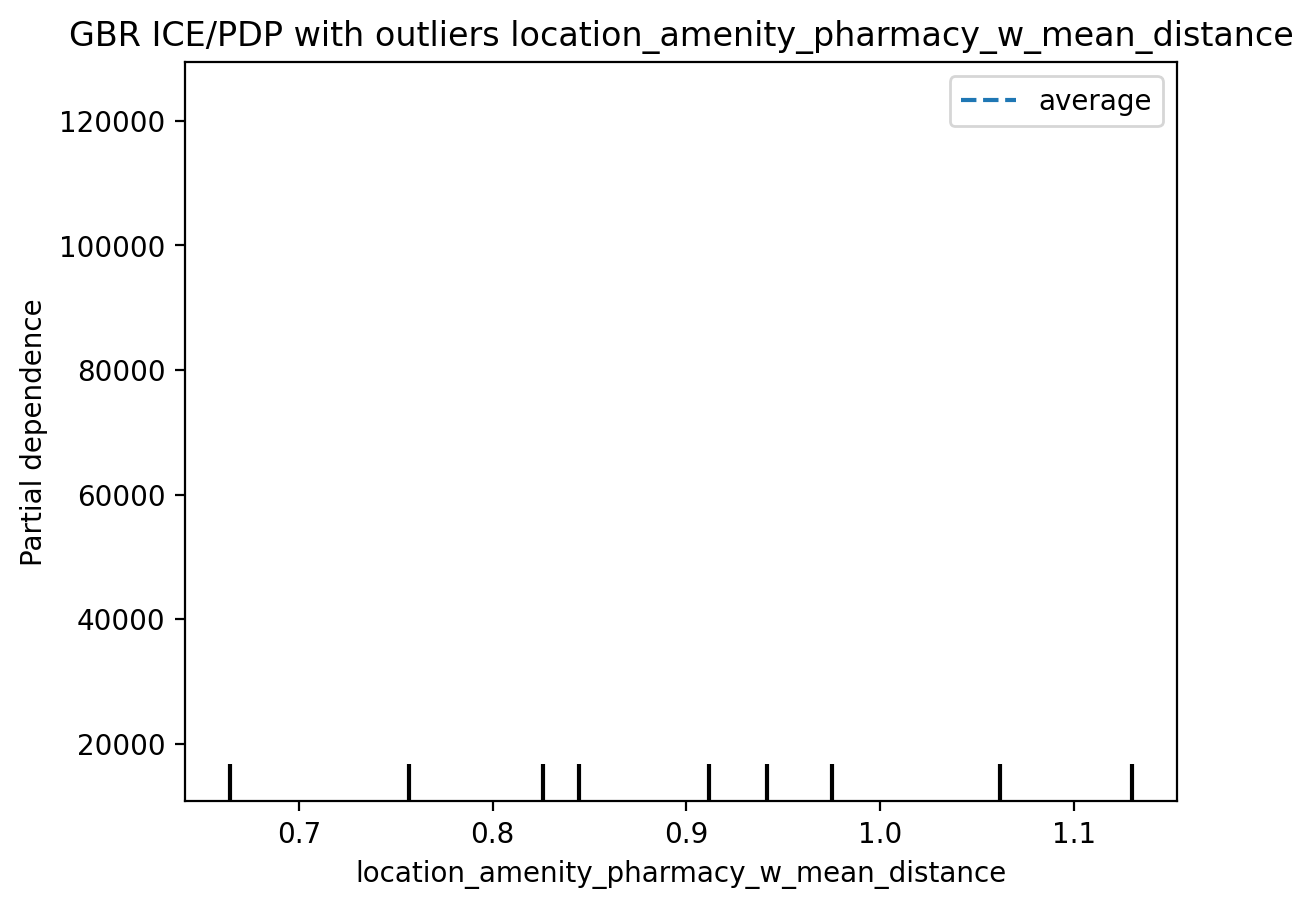

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

df = pd.read_csv(data_path)
df = df.loc[:, ~df.columns.duplicated()]

y = df["price_target"]
X = df.drop(columns=["price_target"]).select_dtypes(include=[np.number])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    MinMaxScaler(),
    LinearRegression()
)

gbr_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    MinMaxScaler(),
    GradientBoostingRegressor(max_depth=5, random_state=42)
)

lr_pipe.fit(X_train, y_train)
gbr_pipe.fit(X_train, y_train)

features = ["floor", "location_amenity_pharmacy_w_mean_distance"]

for f in features:
    PartialDependenceDisplay.from_estimator(
        lr_pipe,
        X_test,
        [f],
        kind="both",
        percentiles=(0, 1),
        grid_resolution=50
    )
    plt.title(f"LR ICE/PDP {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(
        gbr_pipe,
        X_test,
        [f],
        kind="both",
        percentiles=(0, 1),
        grid_resolution=50
    )
    plt.title(f"GBR ICE/PDP {f}")
    plt.show()

X_out = X_test.copy()
out_idx = X_out.sample(n=min(5, len(X_out)), random_state=42).index

for f in features:
    X_out.loc[out_idx, f] = X_train[f].max() + 3 * X_train[f].std()

for f in features:
    PartialDependenceDisplay.from_estimator(
        lr_pipe,
        X_out,
        [f],
        kind="both",
        percentiles=(0, 1),
        grid_resolution=50
    )
    plt.title(f"LR ICE/PDP with outliers {f}")
    plt.show()

    PartialDependenceDisplay.from_estimator(
        gbr_pipe,
        X_out,
        [f],
        kind="both",
        percentiles=(0, 1),
        grid_resolution=50
    )
    plt.title(f"GBR ICE/PDP with outliers {f}")
    plt.show()

## Задание 3. 1 балл
Выберите 20 объектов из тестовой выборки.
Для каждого объекта из выбранного набора построим траекторию изменения предсказания модели при постепенном изменении значения признака от его текущего значения к базовому значению (медиана или среднее по обучающей выборке).

**Алгоритм:**
1. Выбрать объект $x_i$ из тестовой выборки
2. Для интересующего признака $j$:
   - Текущее значение: $x_{i,j}$
   - Базовое значение: $x_{base,j}$ (медиана или среднее по обучающей выборке)
3. Построить линейную интерполяцию между $x_{i,j}$ и $x_{base,j}$ с $n$ шагами
4. Для каждого шага интерполяции:
   - Заменить значение признака $j$ в объекте $x_i$ на значение из интерполяции
   - Вычислить предсказание модели для модифицированного объекта
5. Построить график траектории


Задание 3.1 (*) 1 балл: проанализируйте также еще один признак

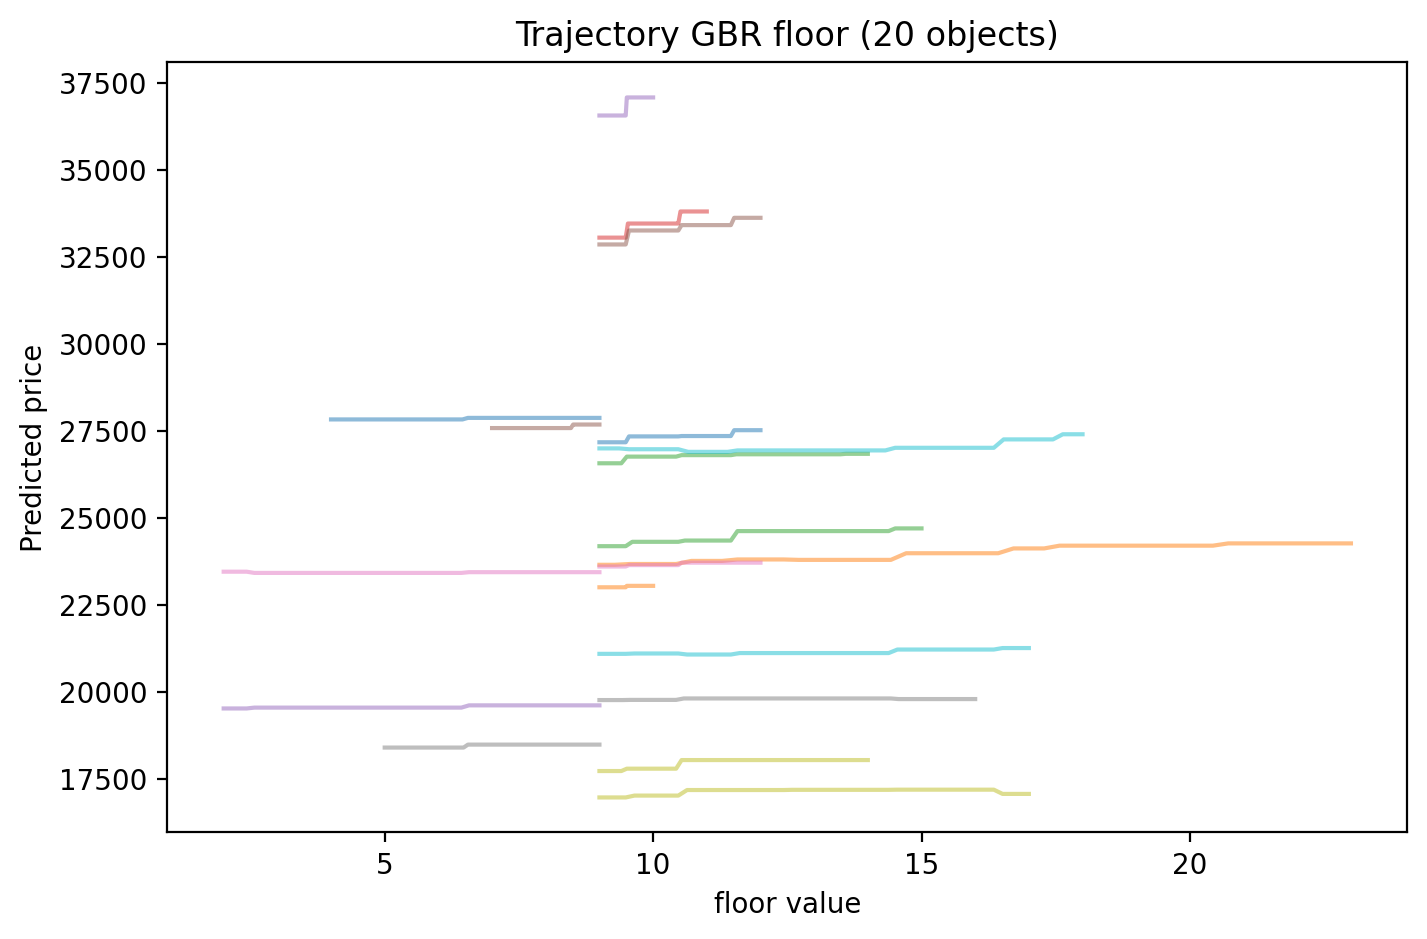

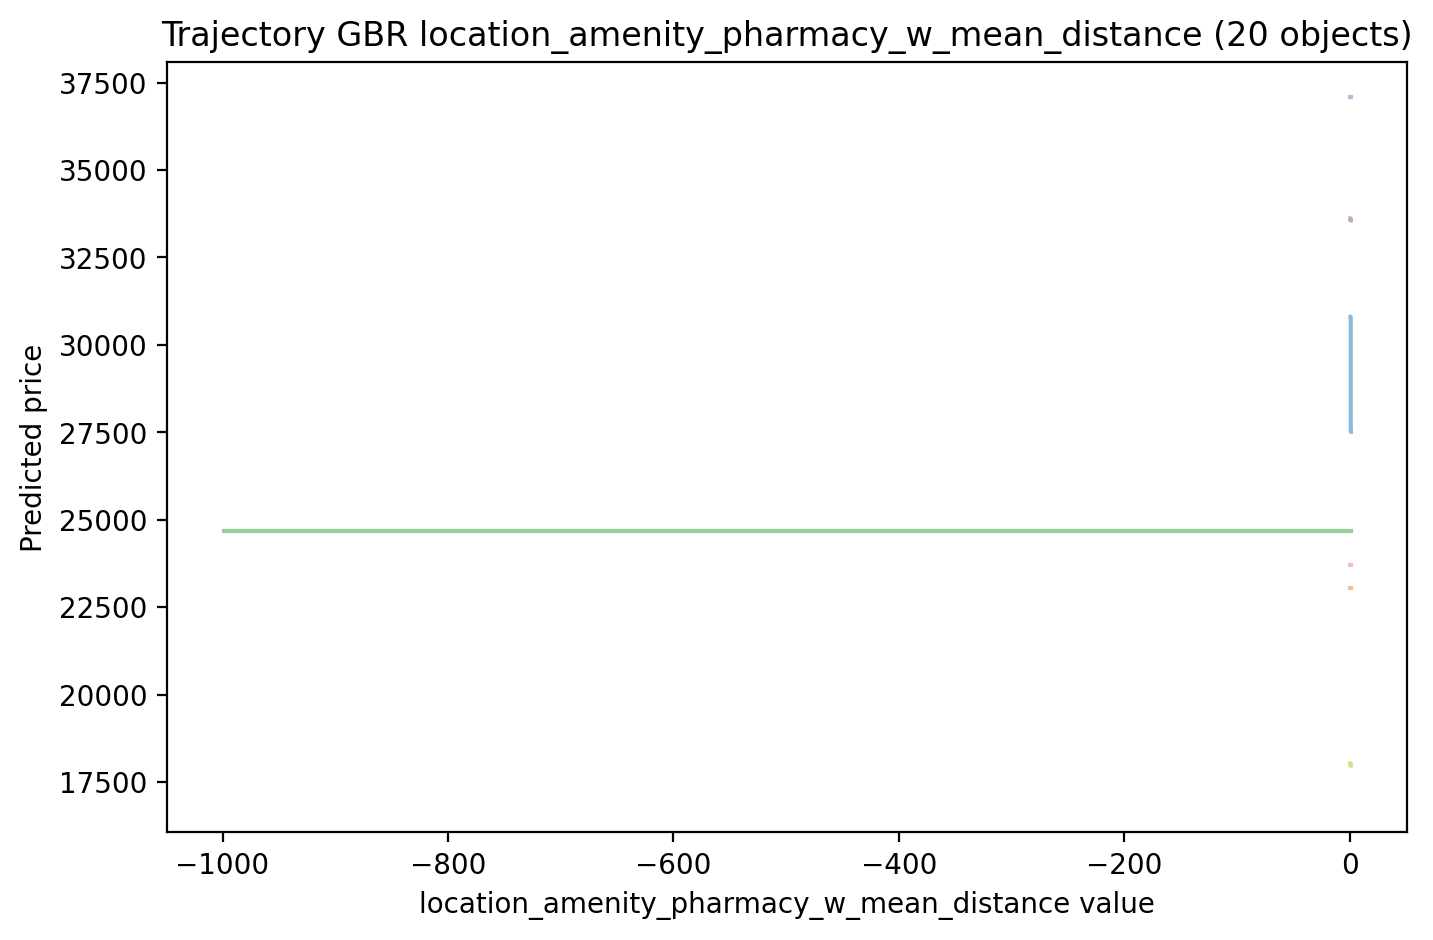

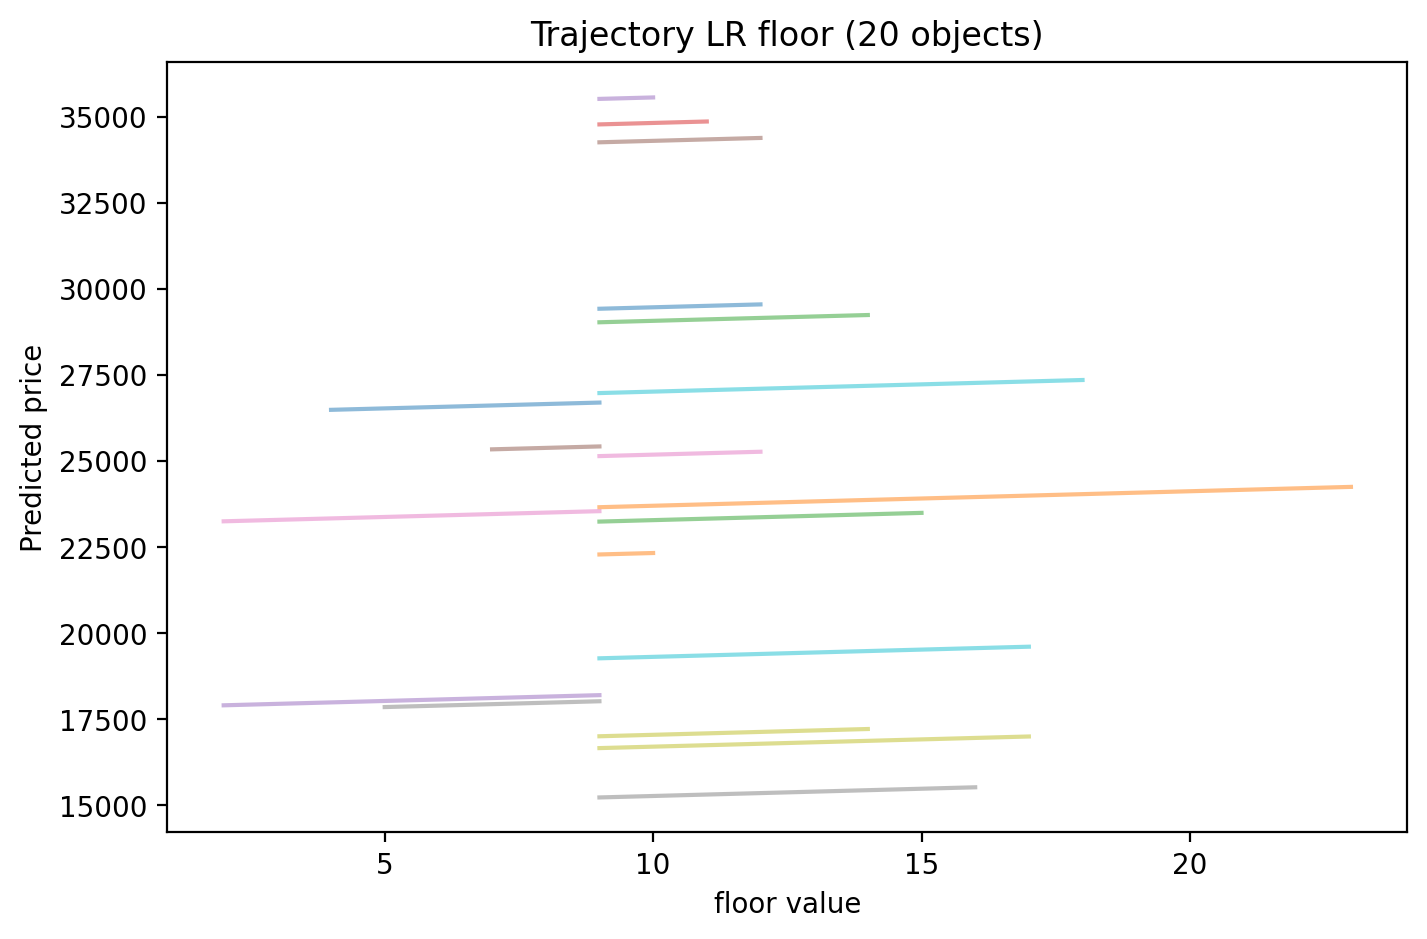

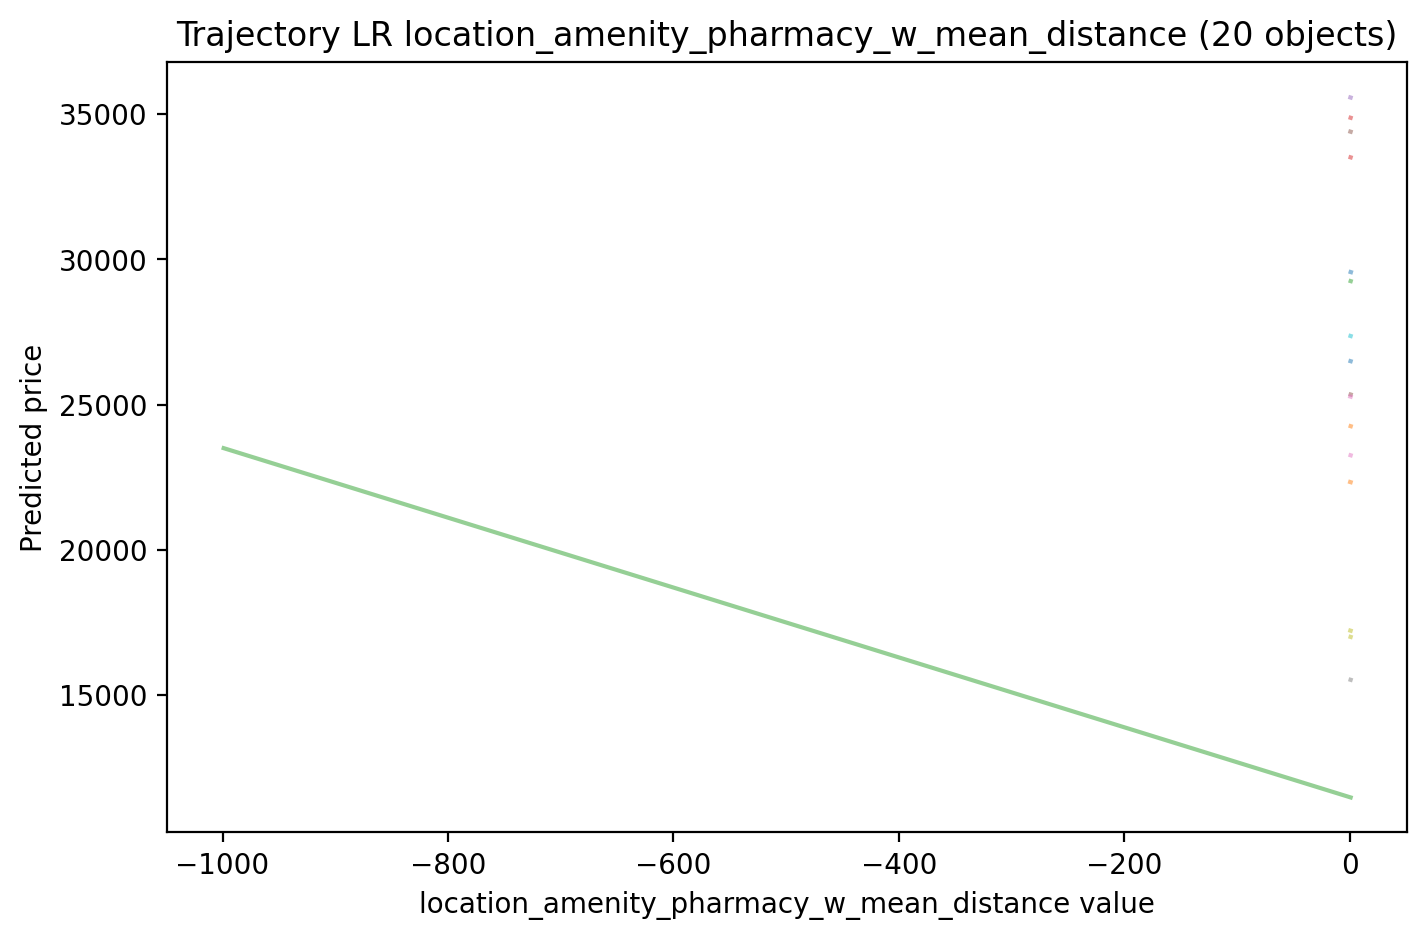

In [6]:
features = ["floor", "location_amenity_pharmacy_w_mean_distance"]
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, 20, replace=False)
n_steps = 50
medians = X_train.median()

for model, name in [(gbr_pipe, "GBR"), (lr_pipe, "LR")]:
    for f in features:
        plt.figure(figsize=(8, 5))
        for idx in sample_idx:
            traj_values = np.linspace(X_test.loc[idx, f], medians[f], n_steps)
            preds = []
            for val in traj_values:
                x_temp = X_test.loc[idx].copy()
                x_temp[f] = val
                preds.append(model.predict(pd.DataFrame([x_temp]))[0])
            plt.plot(traj_values, preds, alpha=0.5)
        plt.xlabel(f"{f} value")
        plt.ylabel("Predicted price")
        plt.title(f"Trajectory {name} {f} (20 objects)")
        plt.show()

## Задание 4 (1 балл). ALE
Постройте ALE по обеим моделям, используя pyALE. Подберите размер сетки так, чтобы получить доверительные интервалы. Проанализируйте полученный график. Каковы получились доверительные интервалы? Почему они различны для моделей?

P.s. Сетку значений стройте для исходного признака.

PyALE._ALE_generic:INFO: Continuous feature detected.


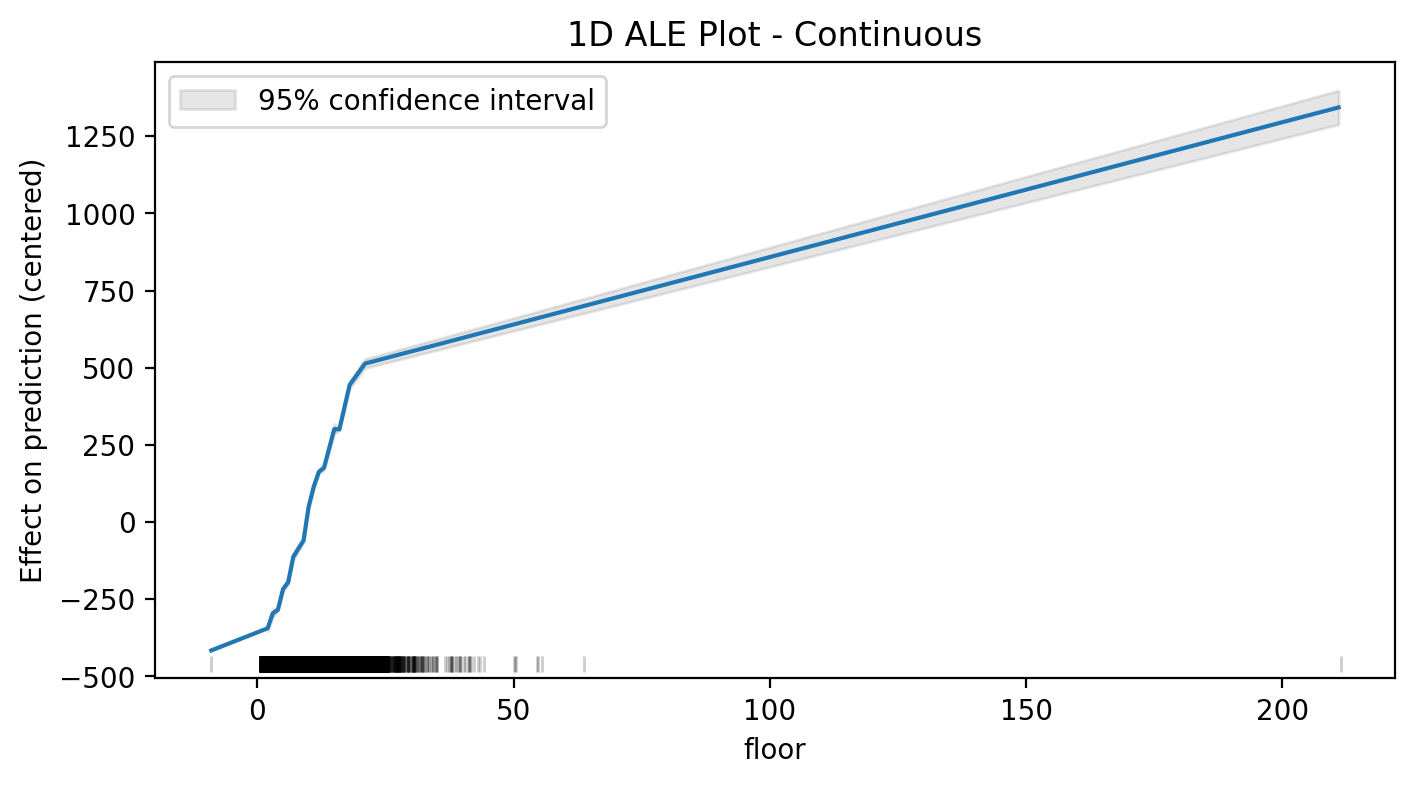

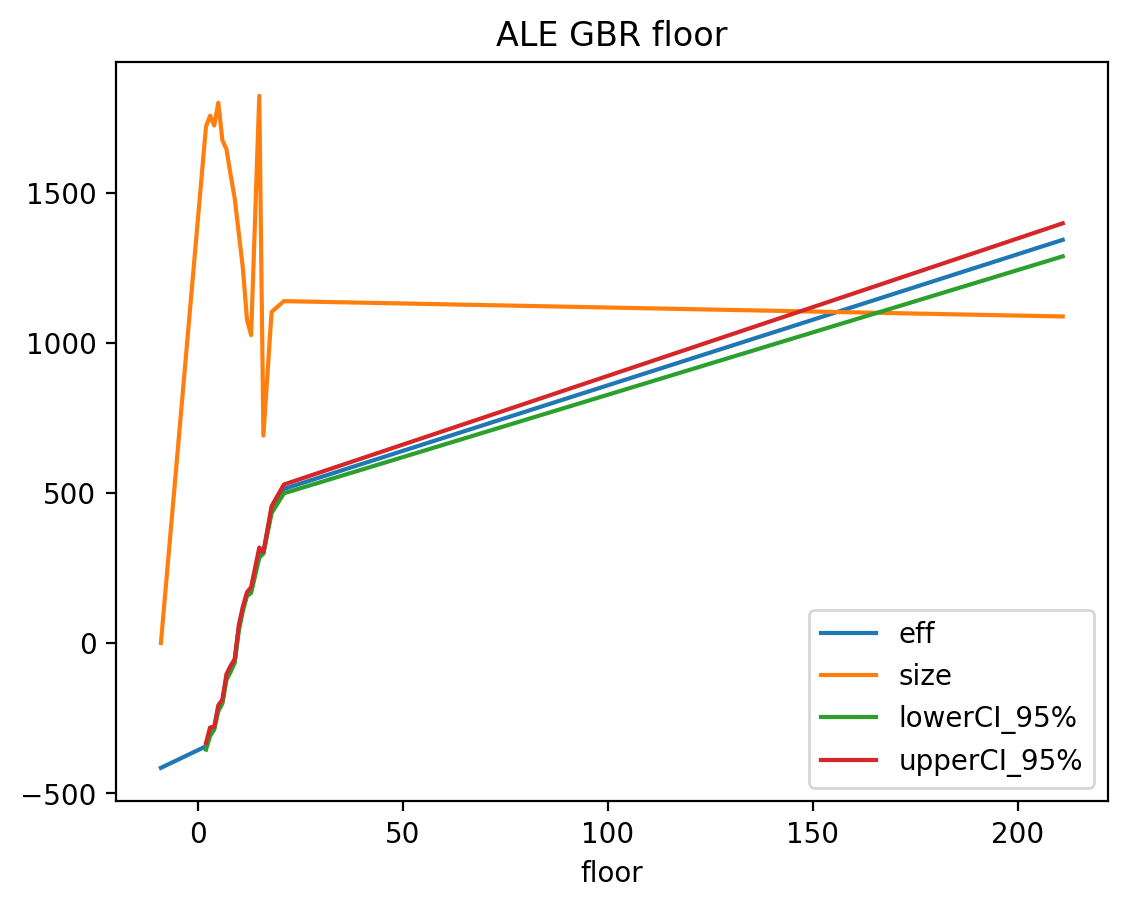

PyALE._ALE_generic:INFO: Continuous feature detected.


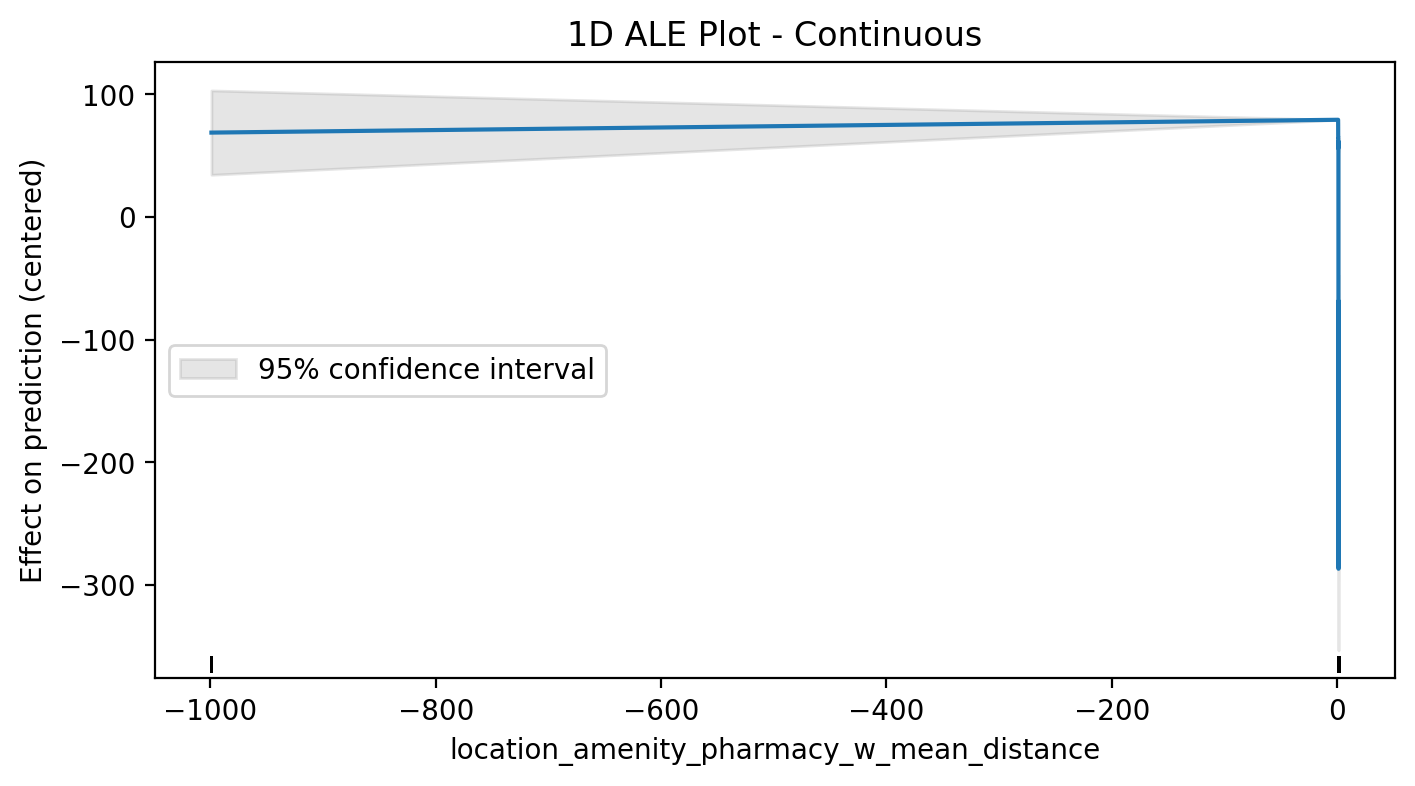

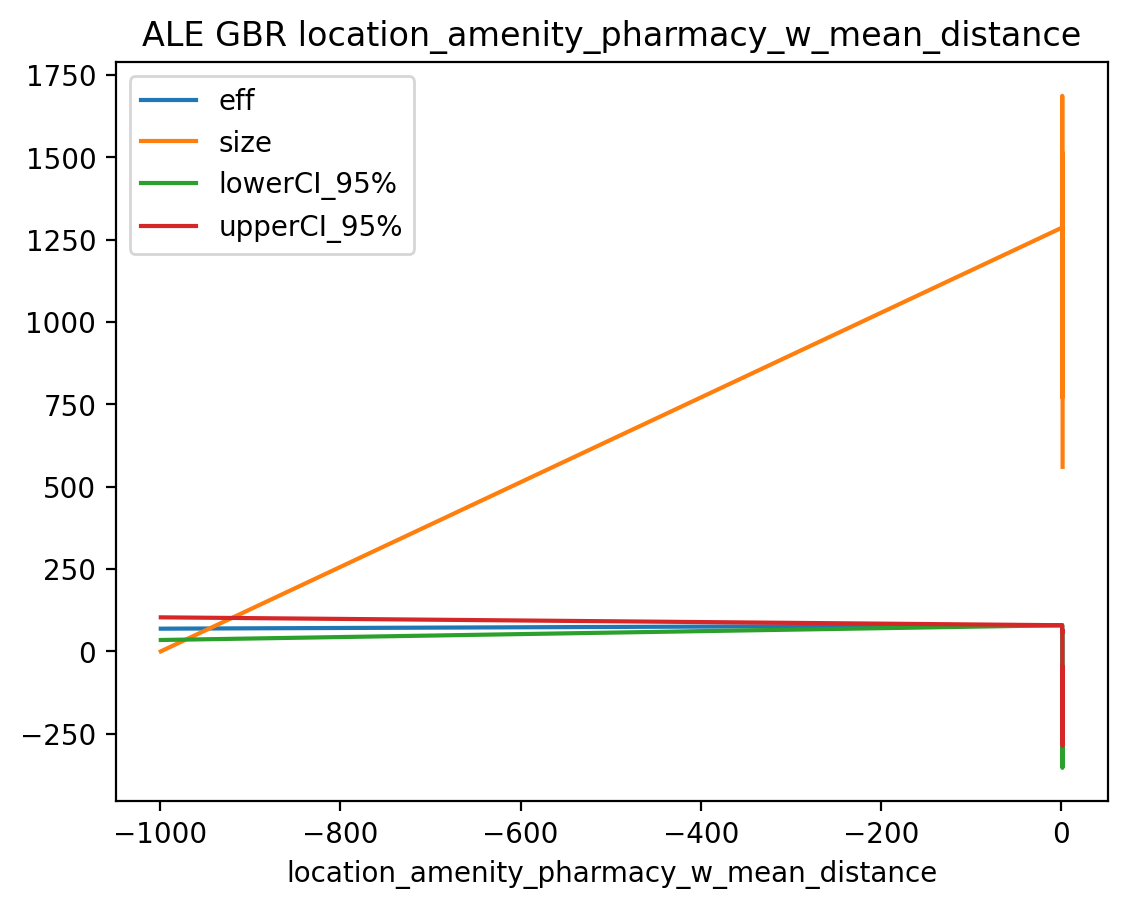

PyALE._ALE_generic:INFO: Continuous feature detected.


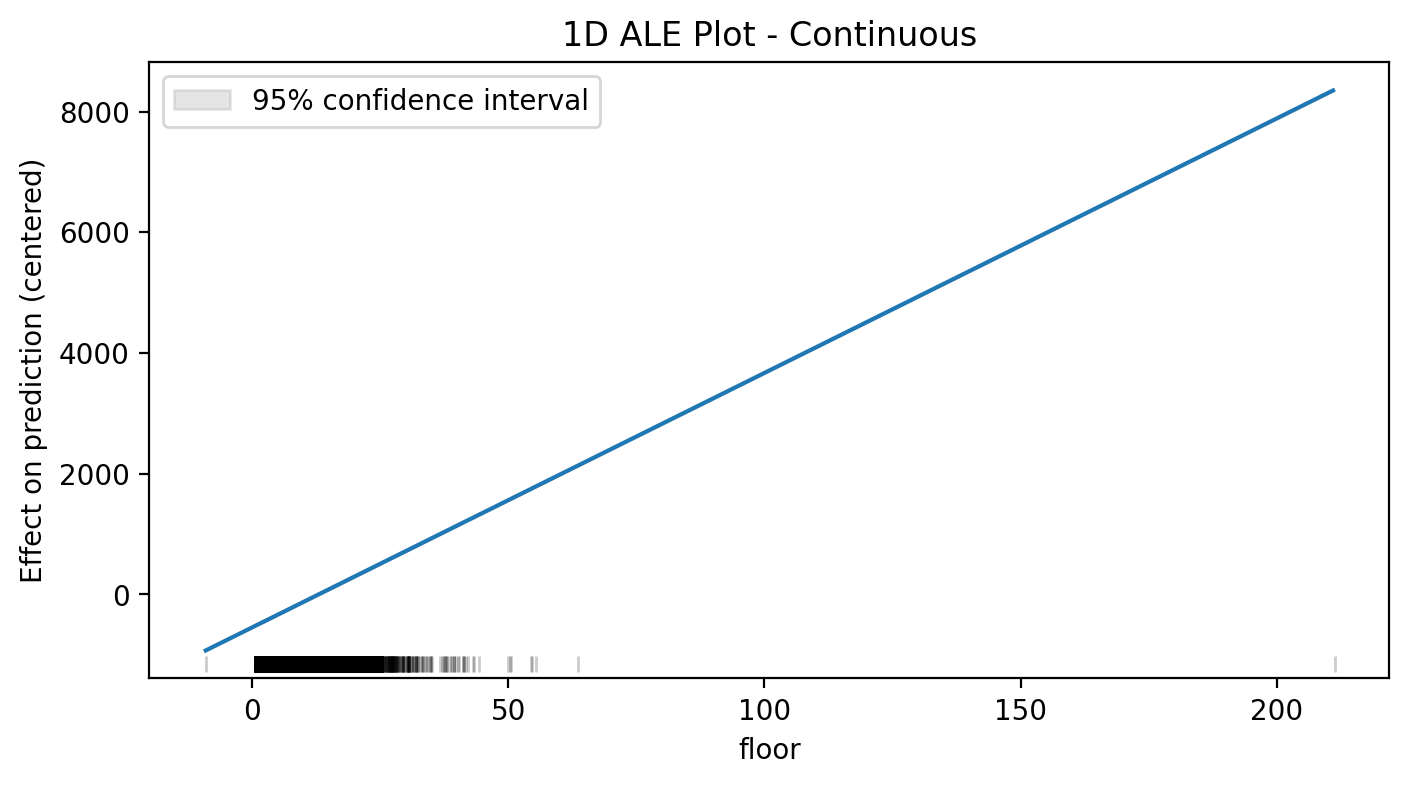

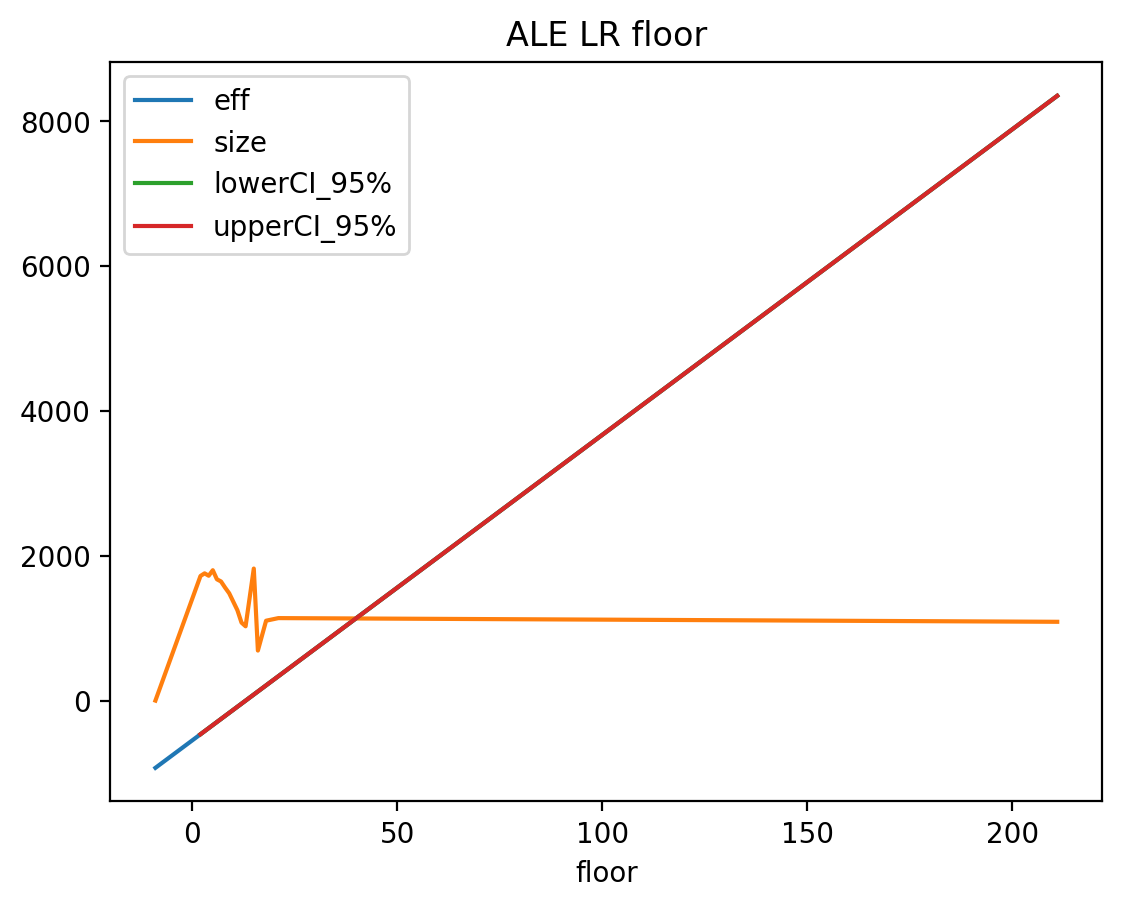

PyALE._ALE_generic:INFO: Continuous feature detected.


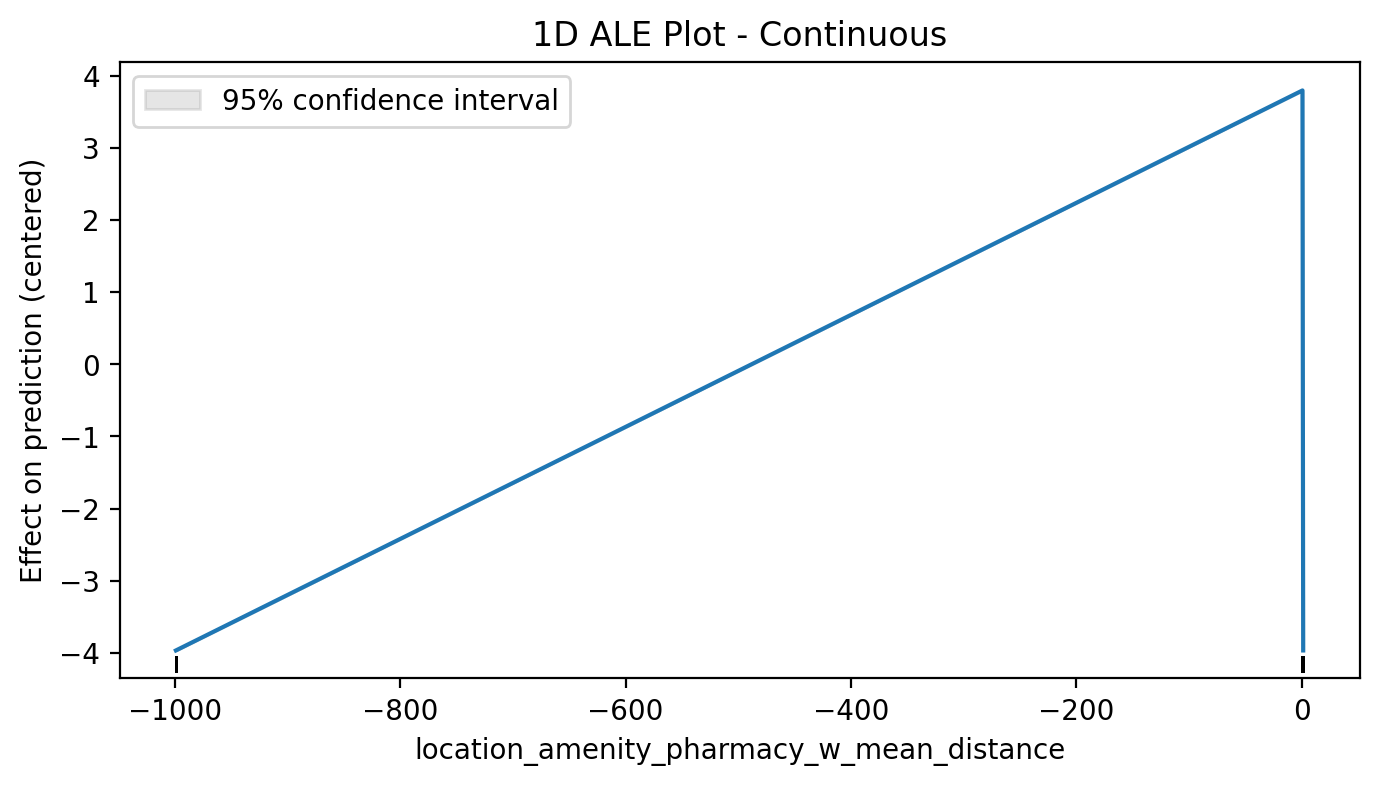

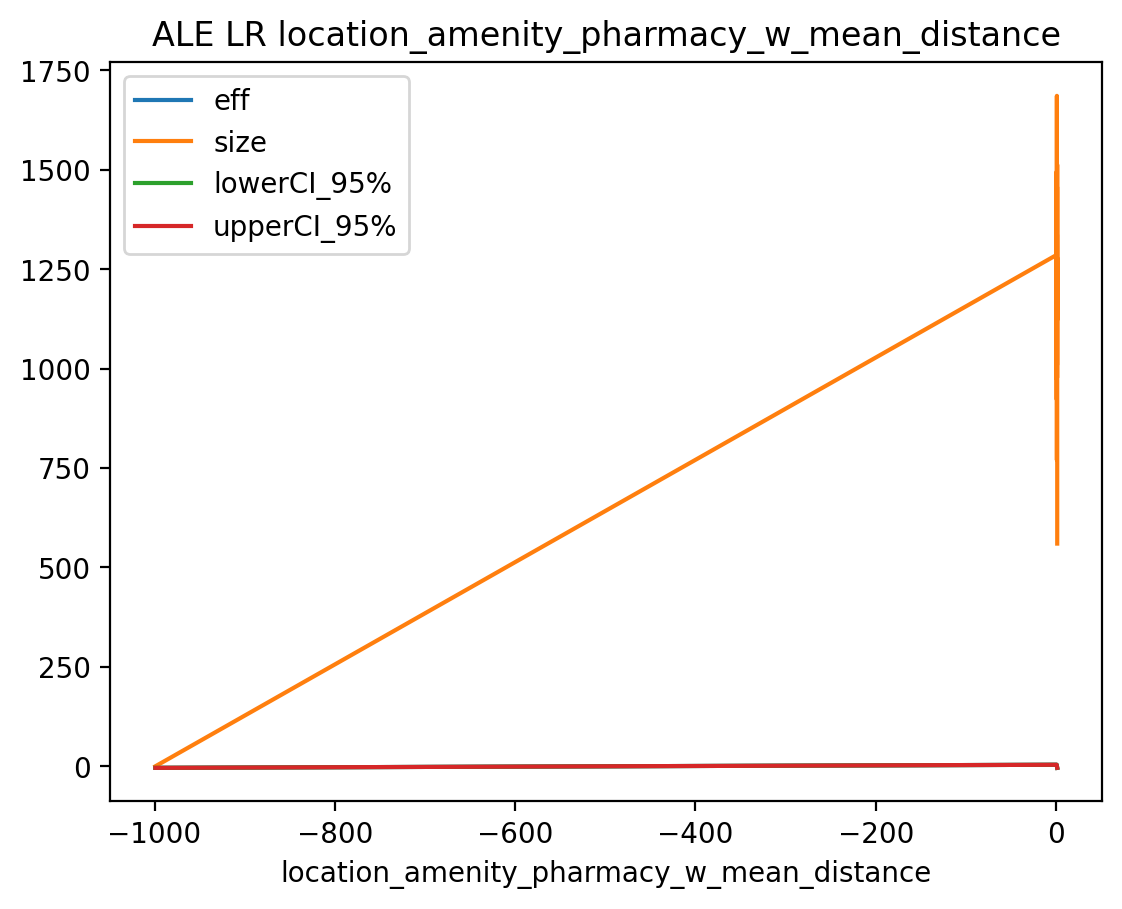

In [7]:
features = ["floor", "location_amenity_pharmacy_w_mean_distance"]

for model, name in [(gbr_pipe, "GBR"), (lr_pipe, "LR")]:
    for f in features:
        ale_eff = ale(
            X=X_train,
            model=model,
            feature=[f],
            grid_size=20,
            include_CI=True,
            C=0.95
        )
        ale_eff.plot()
        plt.title(f"ALE {name} {f}")
        plt.show()

## Задание 5:  Permutation Importance (2 балла)
Постройте Permutation importances по обеим моделям, используя sklearn.

Поэкспериментируйте с числом перестановок.

Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов?



Permutation Importance: GBR


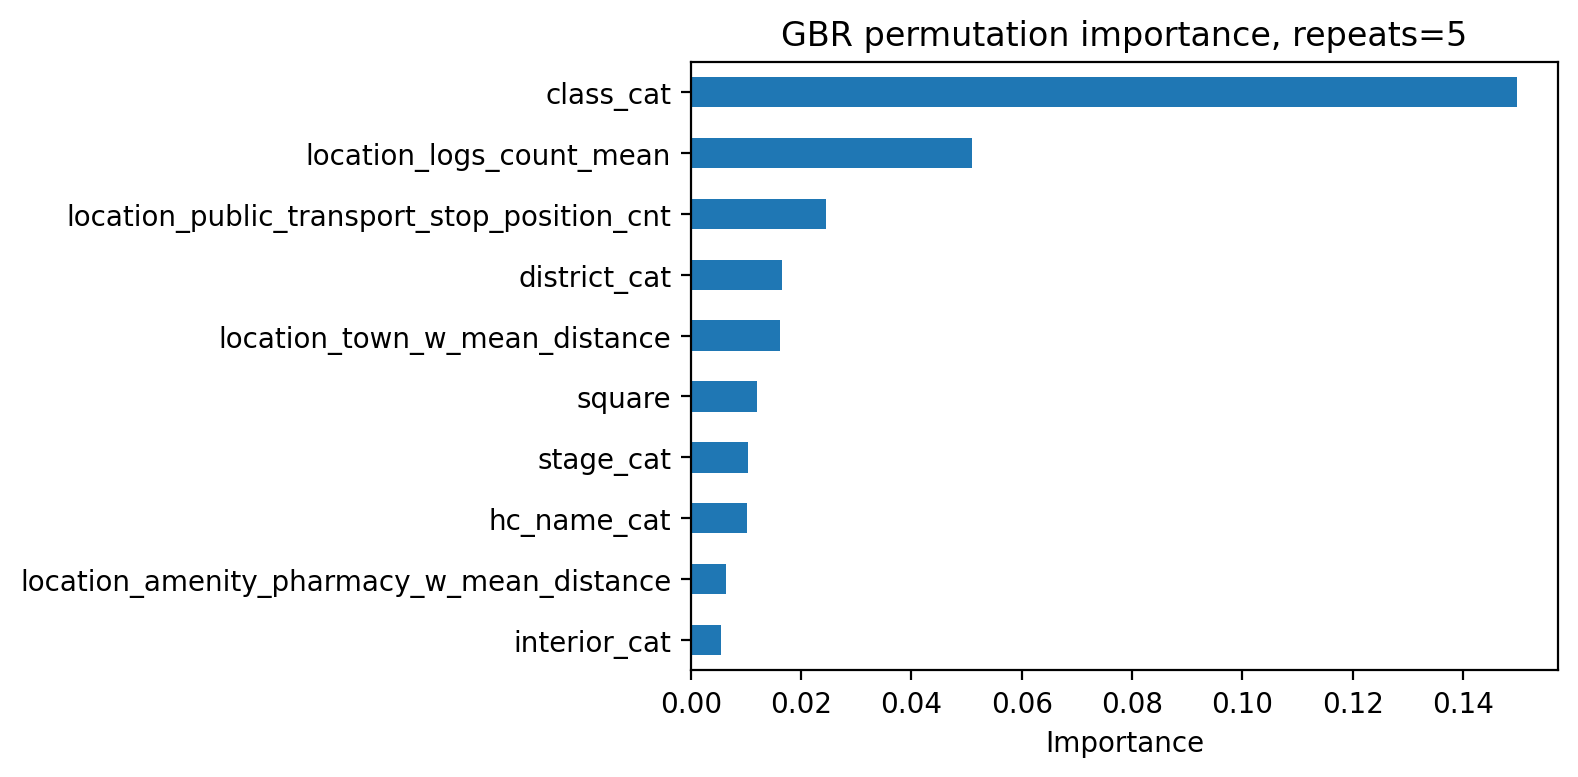

,mean,std
class_cat,0.149715,0.002482
location_logs_count_mean,0.050944,0.001130
location_public_transport_stop_position_cnt,0.024449,0.000193
district_cat,0.016461,0.000382
location_town_w_mean_distance,0.016196,0.000323
square,0.012098,0.000181
stage_cat,0.010438,0.000269
hc_name_cat,0.010244,0.000323
location_amenity_pharmacy_w_mean_distance,0.006330,0.000266
interior_cat,0.005523,0.000182


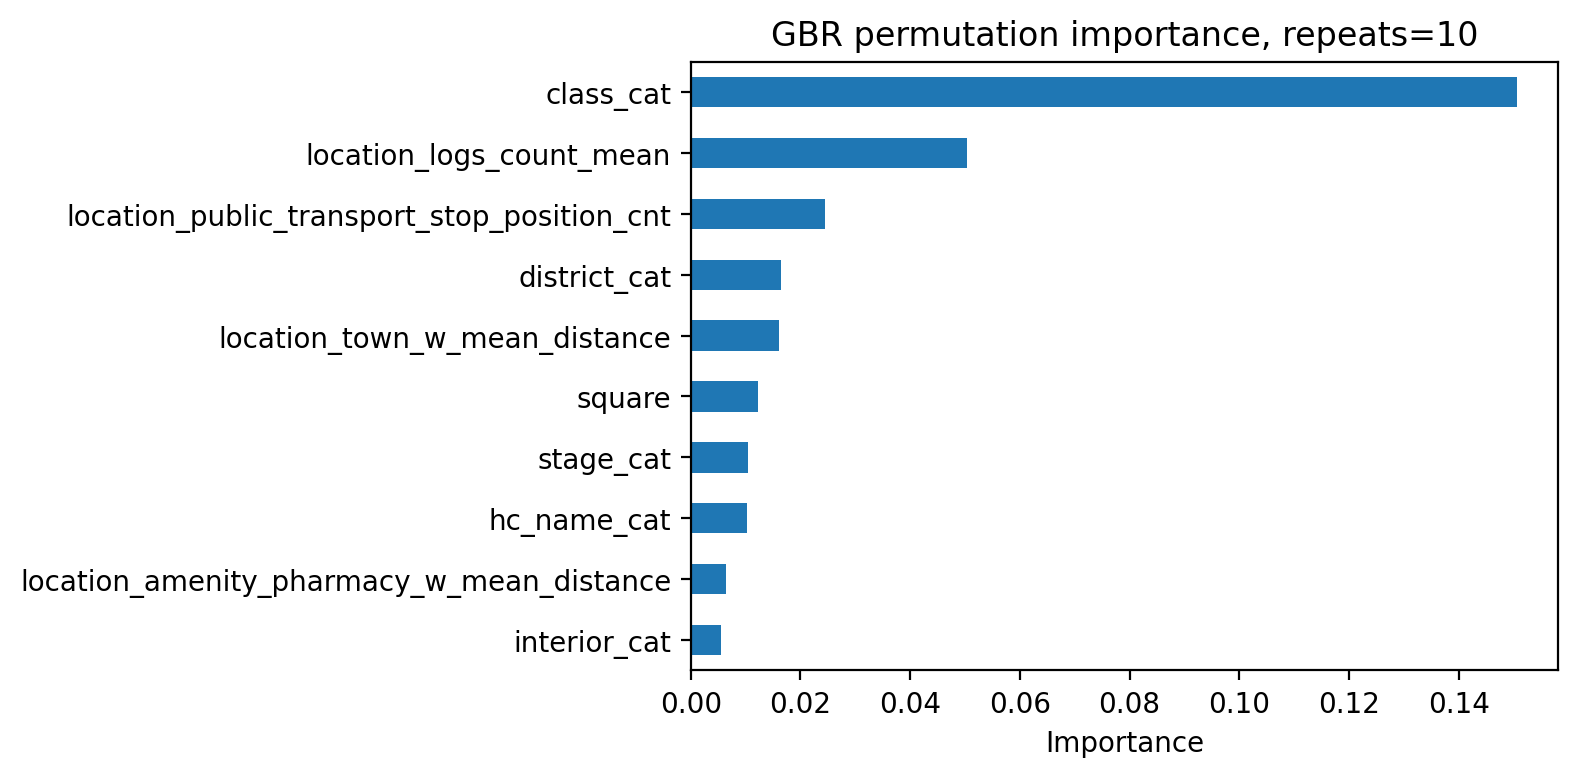

,mean,std
class_cat,0.150556,0.002491
location_logs_count_mean,0.050386,0.001151
location_public_transport_stop_position_cnt,0.024431,0.000365
district_cat,0.016408,0.000527
location_town_w_mean_distance,0.016085,0.000300
square,0.012178,0.000204
stage_cat,0.010440,0.000204
hc_name_cat,0.010263,0.000251
location_amenity_pharmacy_w_mean_distance,0.006356,0.000264
interior_cat,0.005522,0.000183


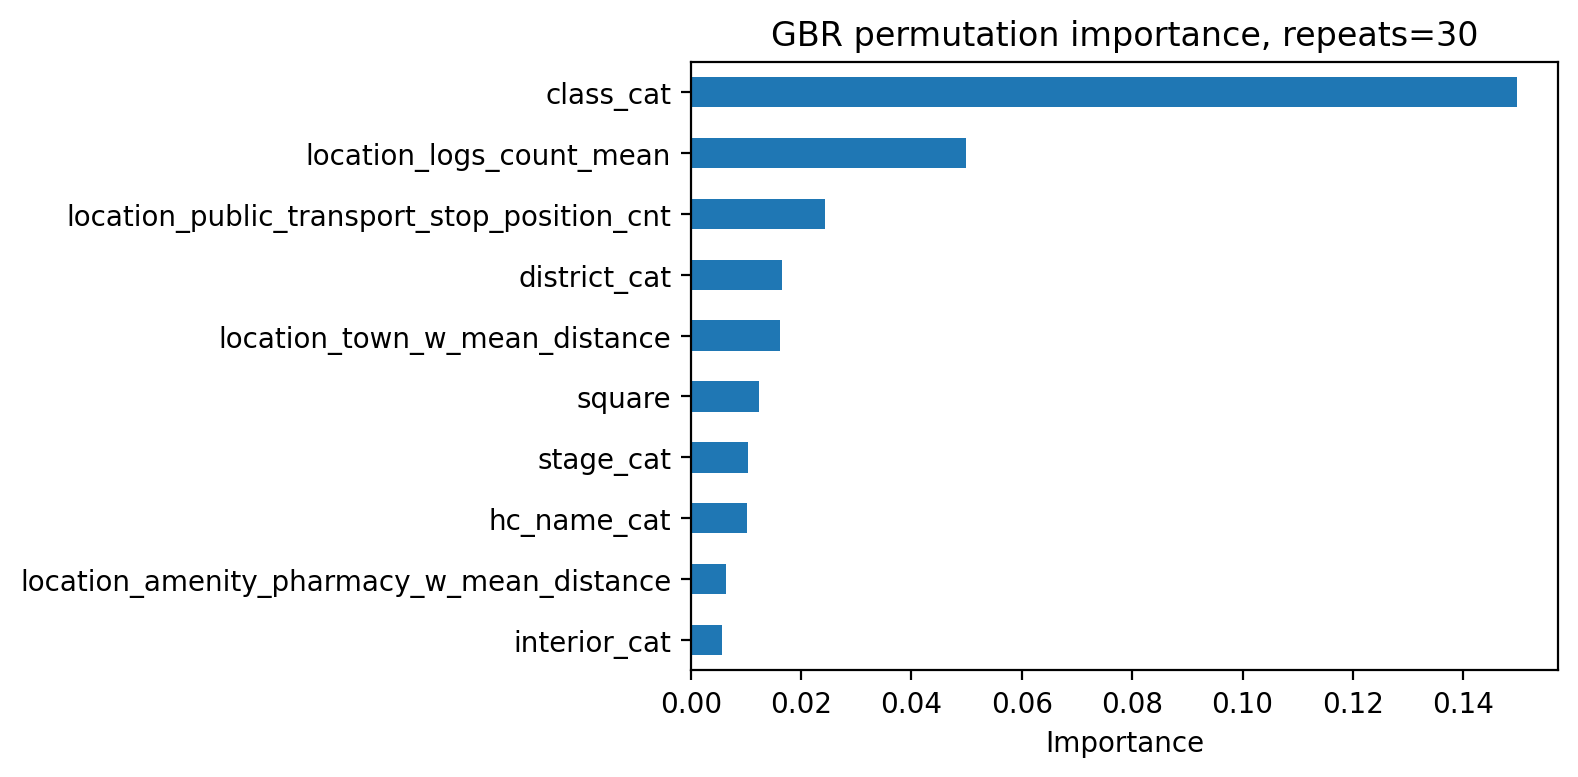

,mean,std
class_cat,0.149676,0.002353
location_logs_count_mean,0.049832,0.001066
location_public_transport_stop_position_cnt,0.024412,0.000554
district_cat,0.016562,0.000416
location_town_w_mean_distance,0.016095,0.000343
square,0.012290,0.000290
stage_cat,0.010392,0.000295
hc_name_cat,0.010282,0.000238
location_amenity_pharmacy_w_mean_distance,0.006364,0.000239
interior_cat,0.005592,0.000217


Permutation Importance: LR


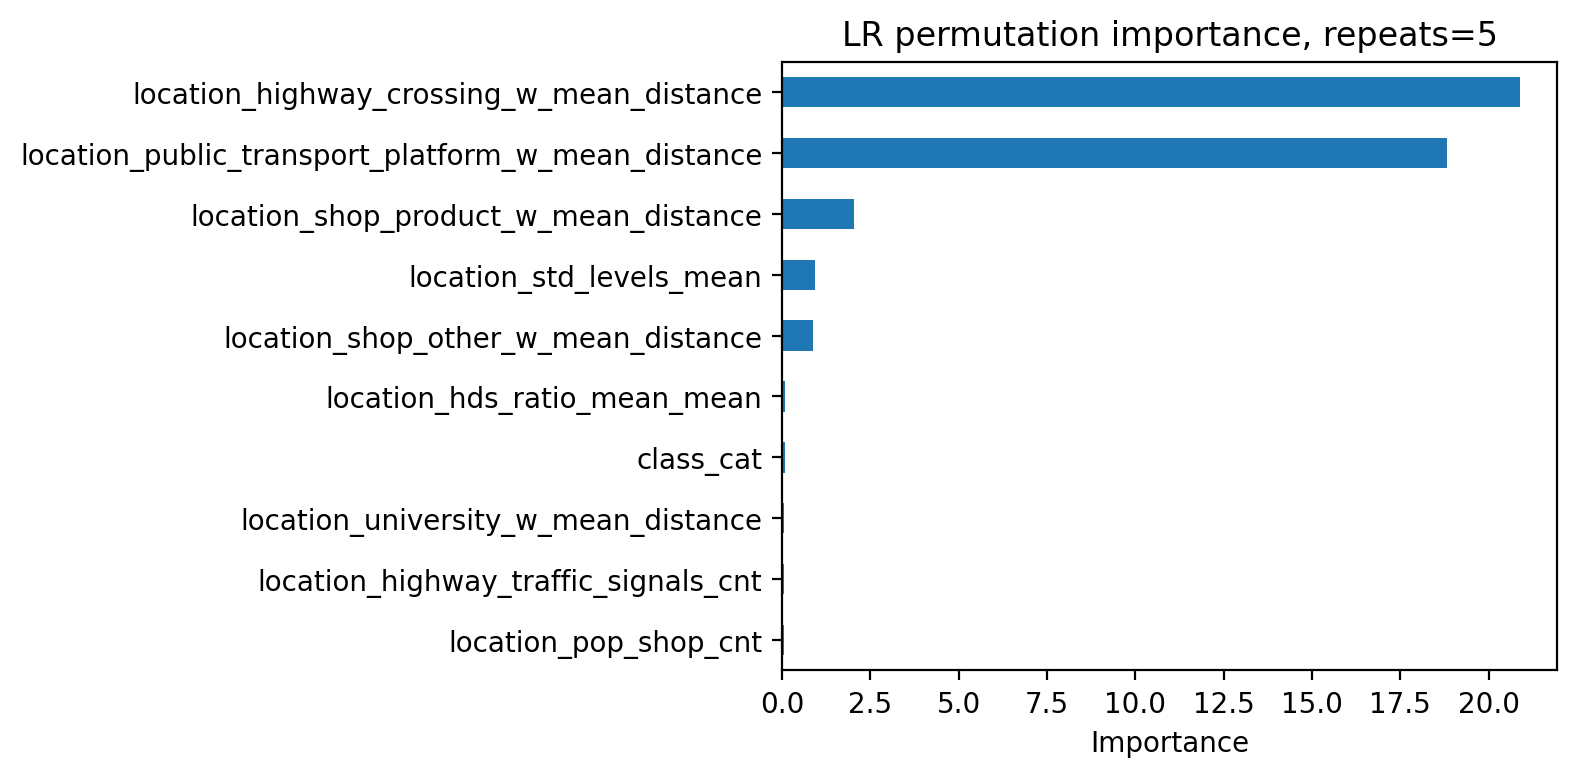

,mean,std
location_highway_crossing_w_mean_distance,20.897696,0.150834
location_public_transport_platform_w_mean_distance,18.833812,0.136466
location_shop_product_w_mean_distance,2.046792,0.014832
location_std_levels_mean,0.946332,0.005919
location_shop_other_w_mean_distance,0.893613,0.005176
location_hds_ratio_mean_mean,0.092836,0.001285
class_cat,0.082108,0.000964
location_university_w_mean_distance,0.074699,0.001054
location_highway_traffic_signals_cnt,0.069436,0.001011
location_pop_shop_cnt,0.062302,0.000647


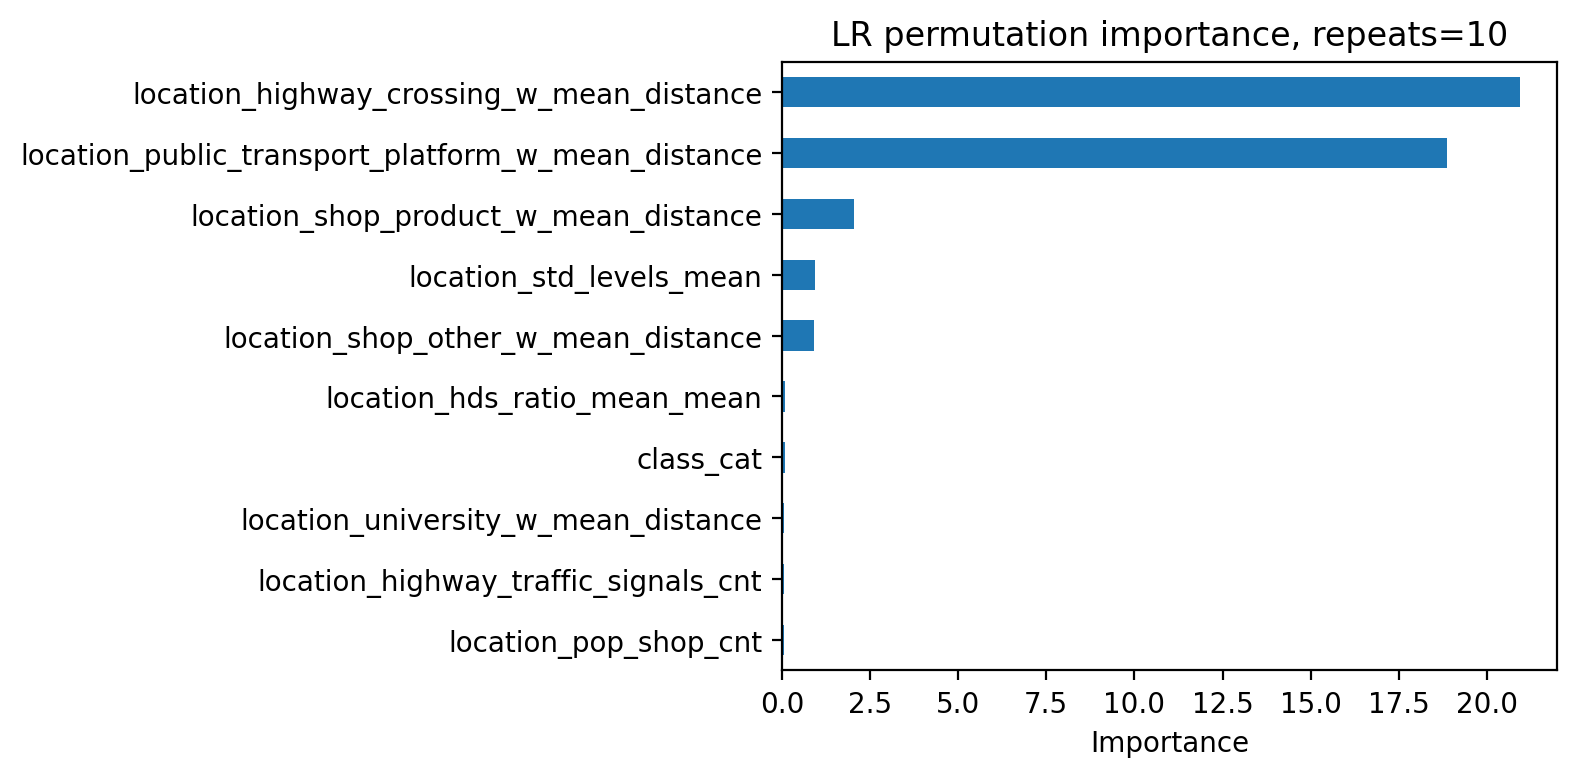

,mean,std
location_highway_crossing_w_mean_distance,20.949932,0.319060
location_public_transport_platform_w_mean_distance,18.880399,0.287598
location_shop_product_w_mean_distance,2.051875,0.031326
location_std_levels_mean,0.952922,0.017201
location_shop_other_w_mean_distance,0.899728,0.016736
location_hds_ratio_mean_mean,0.093142,0.001250
class_cat,0.082798,0.001543
location_university_w_mean_distance,0.074474,0.001334
location_highway_traffic_signals_cnt,0.069927,0.001008
location_pop_shop_cnt,0.062192,0.000840


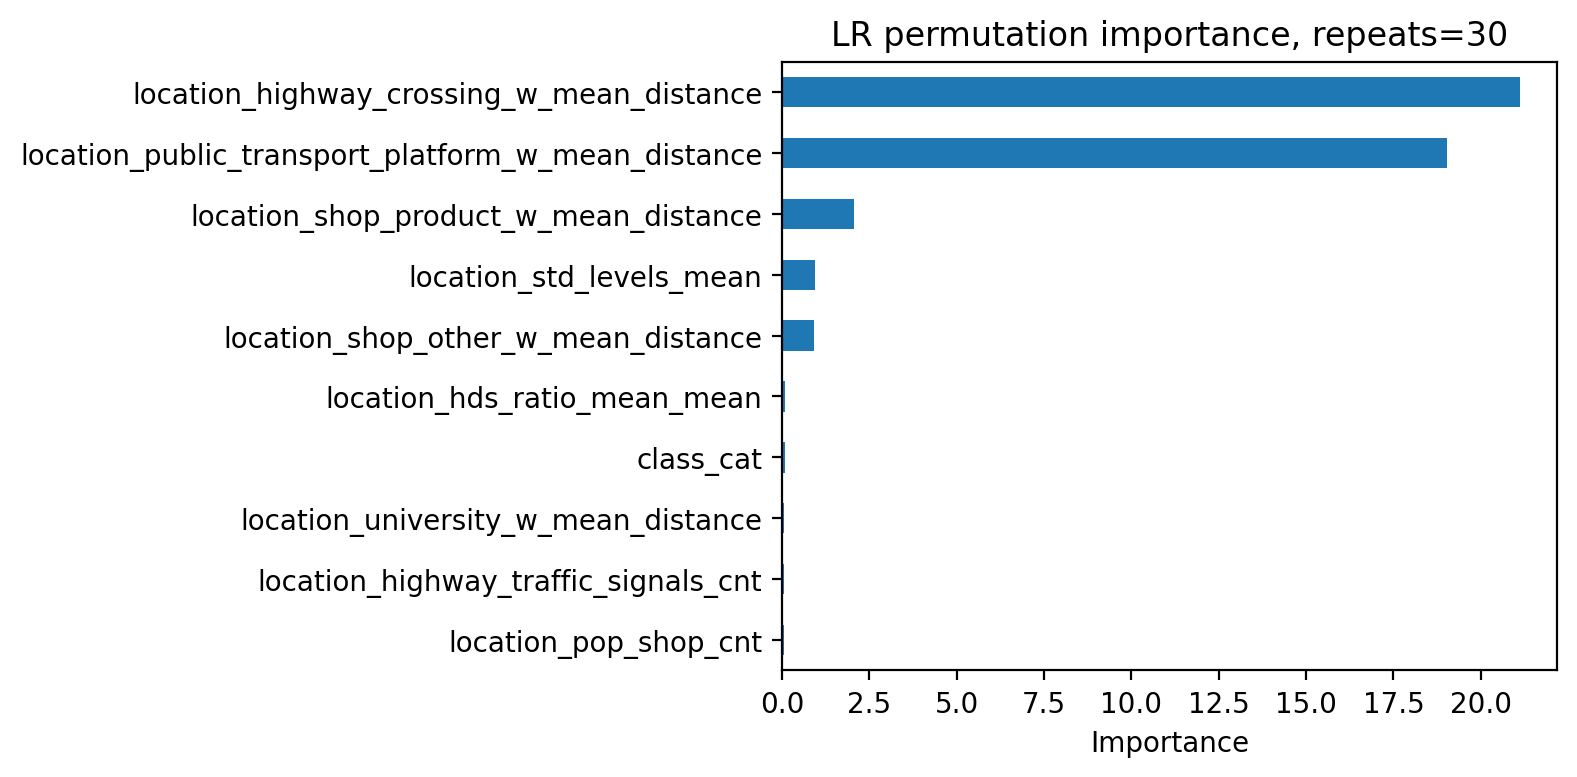

,mean,std
location_highway_crossing_w_mean_distance,21.133170,0.361224
location_public_transport_platform_w_mean_distance,19.045252,0.325475
location_shop_product_w_mean_distance,2.069604,0.035311
location_std_levels_mean,0.961865,0.018702
location_shop_other_w_mean_distance,0.908497,0.018366
location_hds_ratio_mean_mean,0.093040,0.001229
class_cat,0.082608,0.001555
location_university_w_mean_distance,0.074304,0.001372
location_highway_traffic_signals_cnt,0.069842,0.001068
location_pop_shop_cnt,0.062611,0.000905


In [8]:
perm_nums = [5, 10, 30]
models = [(gbr_pipe, "GBR"), (lr_pipe, "LR")]

for model, name in models:
    print(f"Permutation Importance: {name}")
    for n in perm_nums:
        perm = permutation_importance(
            model,
            X_test,
            y_test,
            n_repeats=n,
            random_state=42,
            scoring="neg_mean_absolute_percentage_error"
        )
        imp_mean = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
        imp_std = pd.Series(perm.importances_std, index=X_test.columns).reindex(imp_mean.index)
        top = pd.DataFrame({"mean": imp_mean.head(10), "std": imp_std.head(10)})

        plt.figure(figsize=(8, 4))
        top["mean"].sort_values().plot(kind="barh")
        plt.title(f"{name} permutation importance, repeats={n}")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.show()

        display(top)

## Задание 5: Feature Importance (2 балла)
Пусть важность - это MAPE для тестовых данных. Проведите анализ только для бустинга

Идея перестановочной важности представляет собой частный случай важности при помощи внесения возмущений в признак. Примеры возмущений:
1) внесение случайного шума
2) зануление признака
3) сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели 

Примем за базовое значение (${base}$)медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:
$x_j^\beta = (1- \beta)x_j + \beta {base}$

Реализуйте это возмущение. Как меняются важности при разных $\beta$?

Постройте графики важности и сравните важности с permutation importance. Используйте только числовые признаки. При этом медиану стоит считать на тренировочном наборе, а важность как разницу MAPE на тестовой выборке. Чем больше разница, тем важнее признак. 


Сравните результаты методов. Какие признаки наиболее важны? Есть ли различия между методами? В чём могут быть причины различий?

Base MAPE: 0.041612


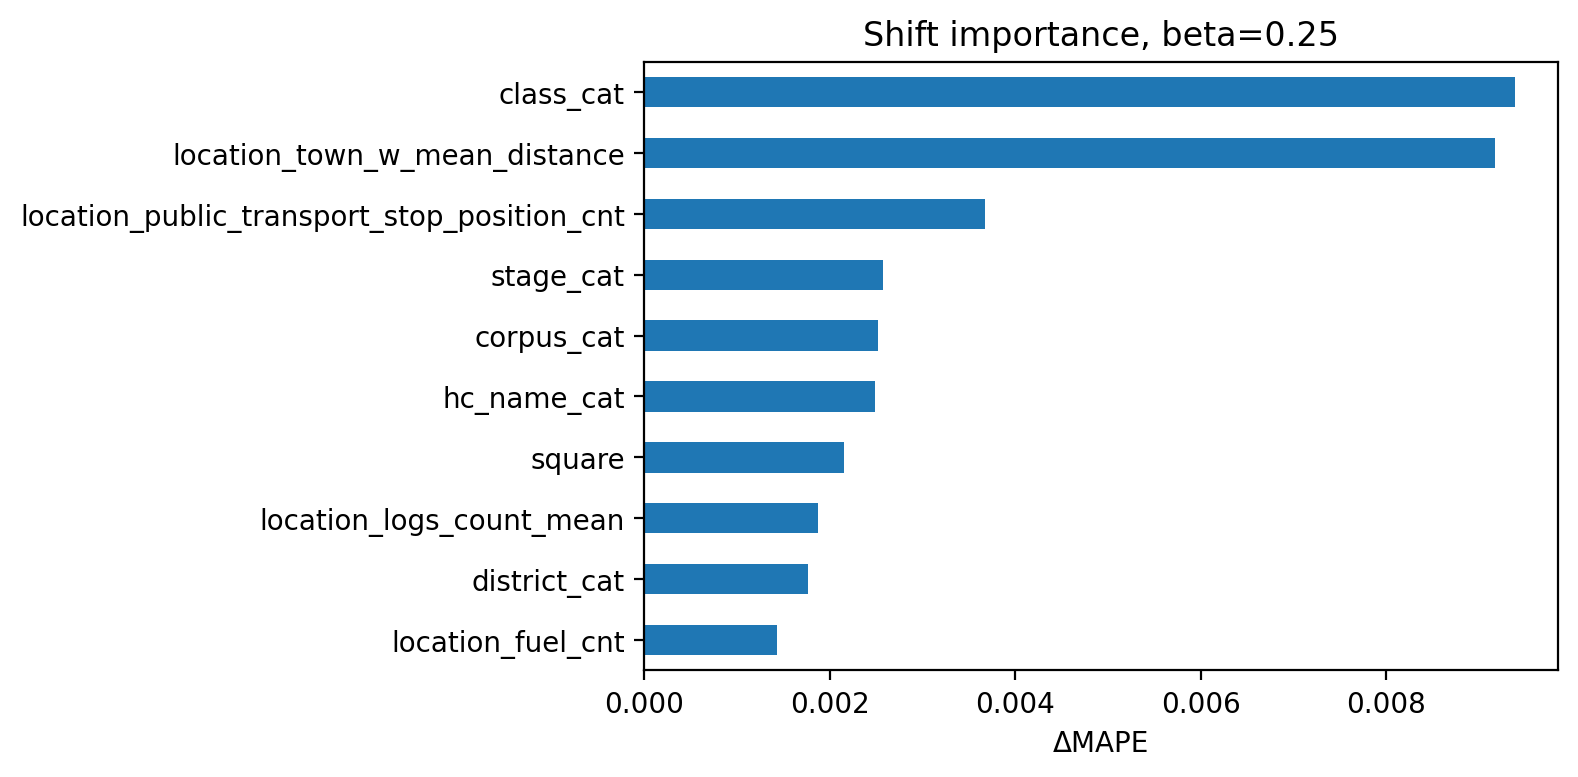

,beta=0.25
class_cat,0.009382
location_town_w_mean_distance,0.009165
location_public_transport_stop_position_cnt,0.003677
stage_cat,0.002576
corpus_cat,0.002524
hc_name_cat,0.002489
square,0.002156
location_logs_count_mean,0.001878
district_cat,0.001766
location_fuel_cnt,0.001429


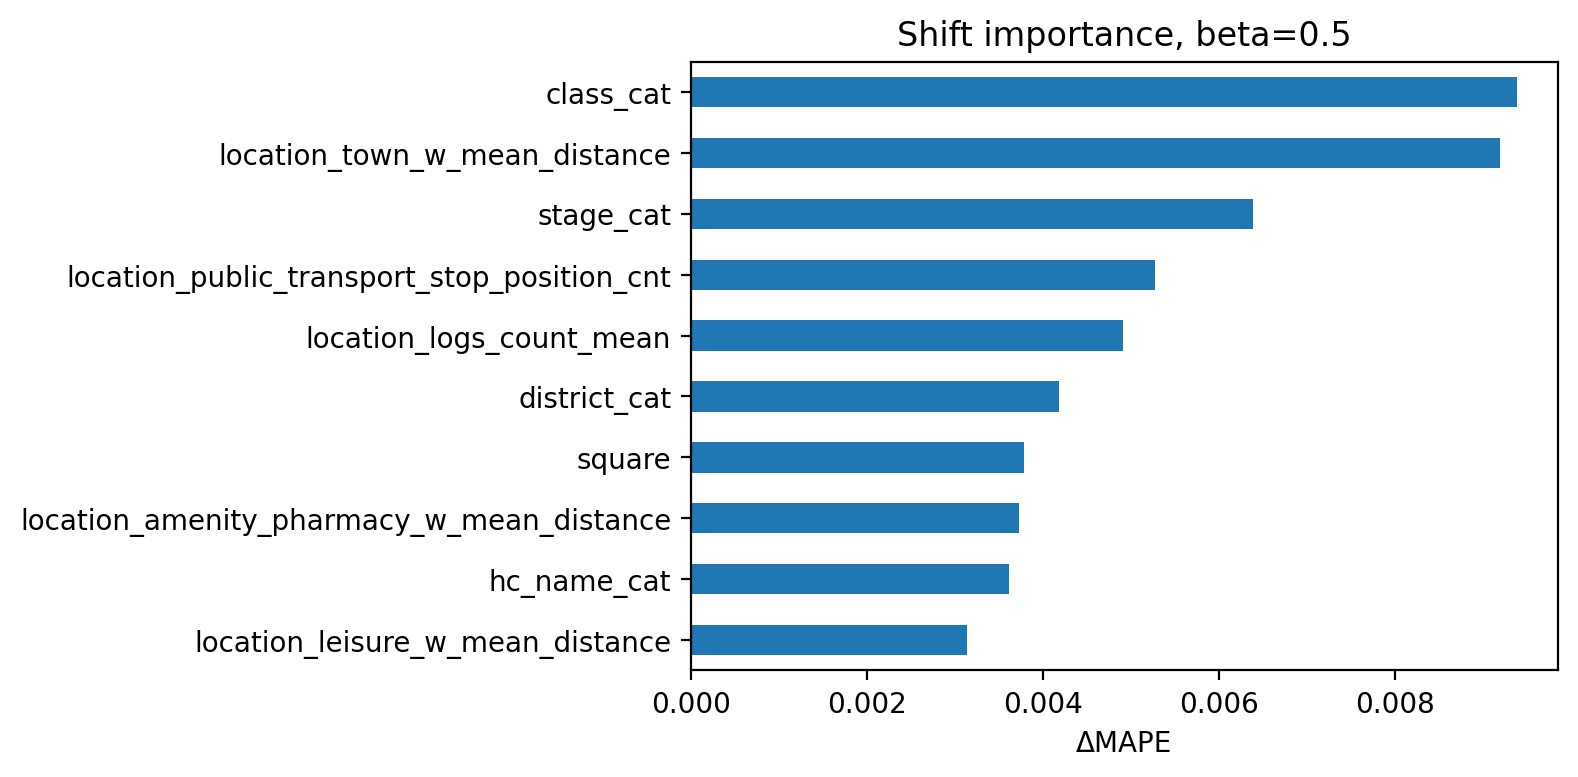

,beta=0.5
class_cat,0.009382
location_town_w_mean_distance,0.009189
stage_cat,0.006383
location_public_transport_stop_position_cnt,0.005269
location_logs_count_mean,0.004912
district_cat,0.004184
square,0.003787
location_amenity_pharmacy_w_mean_distance,0.003723
hc_name_cat,0.003613
location_leisure_w_mean_distance,0.003136


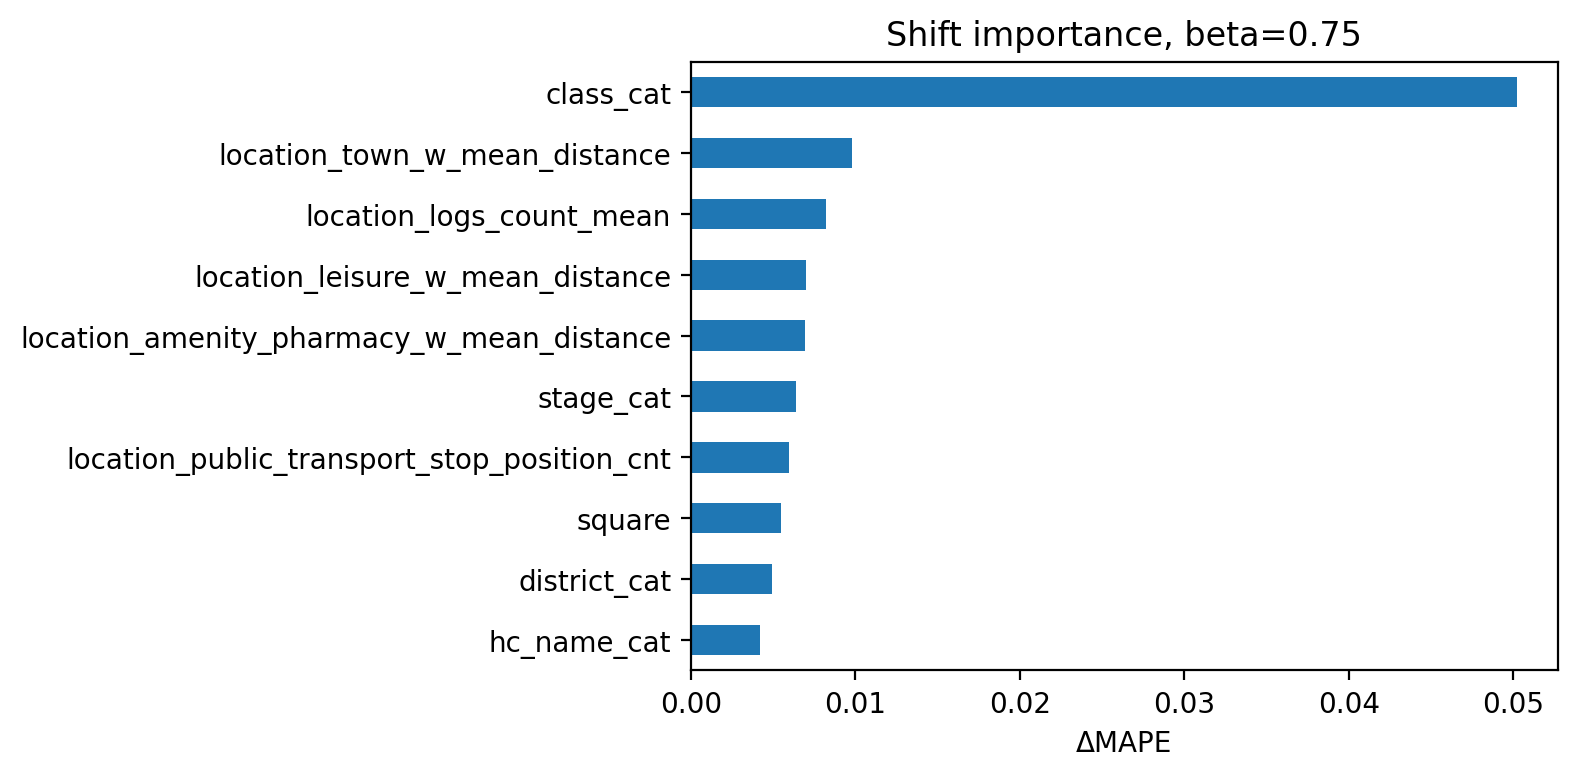

,beta=0.75
class_cat,0.050200
location_town_w_mean_distance,0.009775
location_logs_count_mean,0.008242
location_leisure_w_mean_distance,0.006980
location_amenity_pharmacy_w_mean_distance,0.006950
stage_cat,0.006370
location_public_transport_stop_position_cnt,0.005952
square,0.005512
district_cat,0.004911
hc_name_cat,0.004209


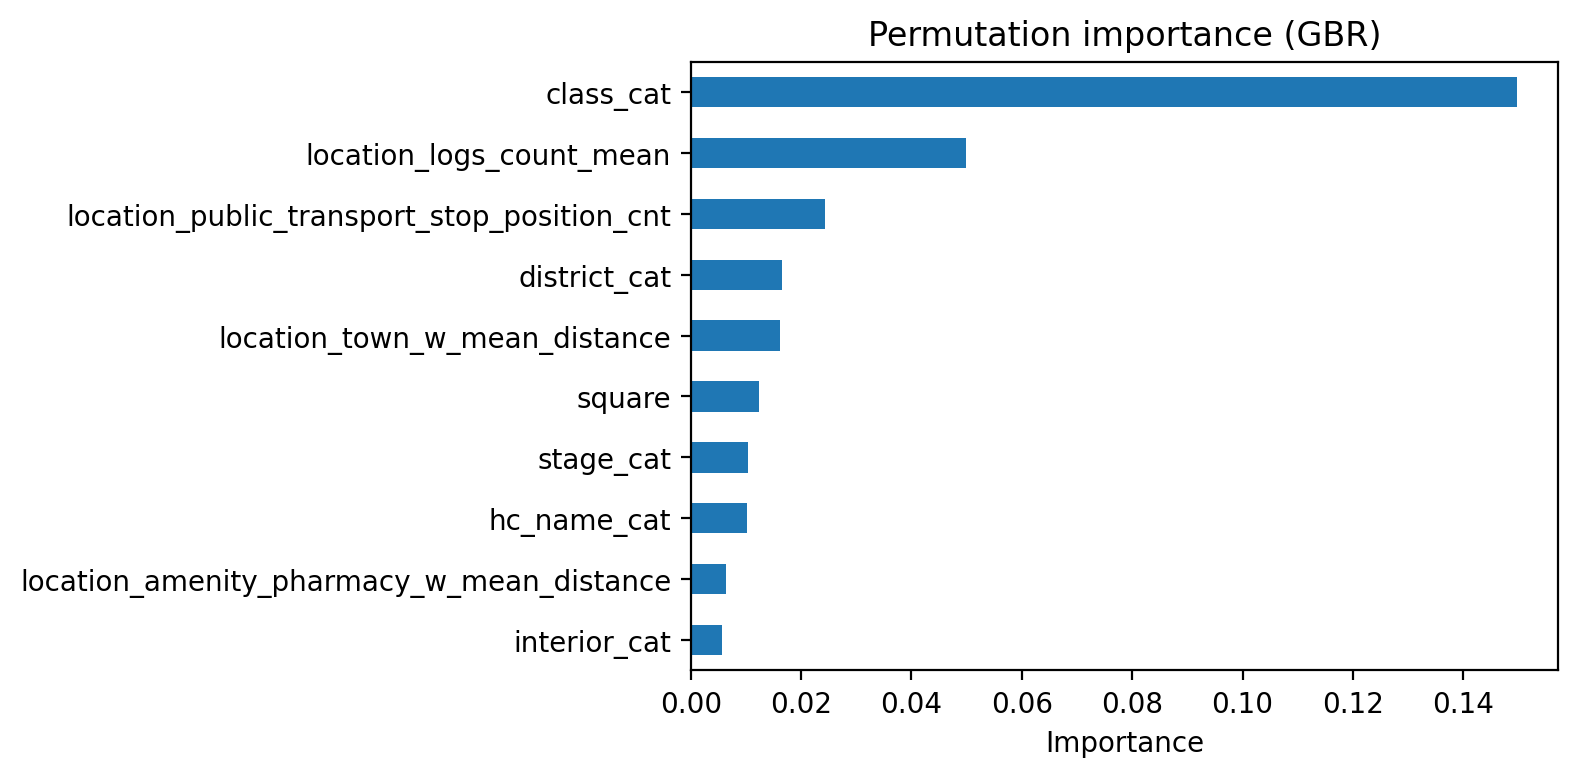

,permutation
class_cat,0.149676
location_logs_count_mean,0.049832
location_public_transport_stop_position_cnt,0.024412
district_cat,0.016562
location_town_w_mean_distance,0.016095
square,0.012290
stage_cat,0.010392
hc_name_cat,0.010282
location_amenity_pharmacy_w_mean_distance,0.006364
interior_cat,0.005592


In [9]:
base_mape = mean_absolute_percentage_error(y_test, gbr_pipe.predict(X_test))
medians = X_train.median()

def shifted_importance(beta):
    vals = {}
    for f in X_test.columns:
        Xp = X_test.copy()
        Xp[f] = (1 - beta) * Xp[f] + beta * medians[f]
        vals[f] = mean_absolute_percentage_error(y_test, gbr_pipe.predict(Xp)) - base_mape
    return pd.Series(vals).sort_values(ascending=False)

betas = [0.25, 0.5, 0.75]
shift_imp = {beta: shifted_importance(beta) for beta in betas}

print(f"Base MAPE: {base_mape:.6f}")

for beta in betas:
    top = shift_imp[beta].head(10).sort_values()
    plt.figure(figsize=(8, 4))
    top.plot(kind="barh")
    plt.title(f"Shift importance, beta={beta}")
    plt.xlabel("ΔMAPE")
    plt.tight_layout()
    plt.show()
    display(shift_imp[beta].head(10).to_frame(name=f"beta={beta}"))

perm = permutation_importance(
    gbr_pipe,
    X_test,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="neg_mean_absolute_percentage_error"
)

perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
perm_imp.head(10).sort_values().plot(kind="barh")
plt.title("Permutation importance (GBR)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(perm_imp.head(10).to_frame("permutation"))

#  Задание 6. 2 балла. LIME.
Постройте интерпретацию признаков для нескольких примеров с помощью LIME. Можете использовать 
Оцените устойчивость реализации. Как влияет на коэффициенты количество сгенерированных точек? А выбор признаков (lasso/добавление фичей по порядку). А выбор ядра?

(*) Вы получите на 2 балла больше, если используете свою реализацию из задания семинарского ноутбука. В таком случае не забудьте добавить тесты для своей реализации. 




Пример 0
prediction: 33110.9843 true: 33456.0064


,feature,coef
0,region_name_cat,0.0
1,district_cat,0.0
2,corpus_cat,0.0
3,developer_cat,0.0
4,floor,0.0
5,square,0.0
6,rooms_4,0.0
7,location_logs_count_mean,0.0



Пример 1993
prediction: 17259.7426 true: 17371.7882


,feature,coef
0,region_name_cat,0.0
1,district_cat,0.0
2,corpus_cat,0.0
3,developer_cat,0.0
4,floor,0.0
5,square,0.0
6,rooms_4,0.0
7,location_logs_count_mean,0.0



Пример 3987
prediction: 17521.5396 true: 17132.3949


...


Сравнение selection на примере 0


,feature,coef,selection
0,region_name_cat,0.0000,lasso
1,district_cat,0.0000,lasso
2,corpus_cat,0.0000,lasso
3,developer_cat,0.0000,lasso
4,floor,0.0000,lasso
5,square,0.0000,lasso
6,rooms_4,0.0000,lasso
7,location_logs_count_mean,0.0000,lasso
8,class_cat,-20701.3777,order
9,location_logs_count_mean,2960.5517,order


,n_samples,cosine_mean,cosine_std,topk_overlap_mean,topk_overlap_std
0,200,0.0,0.0,1.0,0.0
1,500,0.0,0.0,1.0,0.0
2,1000,0.0,0.0,1.0,0.0
3,2000,0.0,0.0,1.0,0.0
4,5000,0.0,0.0,1.0,0.0


,kernel,cosine_mean,topk_overlap_mean
0,epanechnikov,0.0,1.0
1,exp,0.0,1.0
2,triangular,0.0,1.0
3,uniform,0.0,1.0


,selection,cosine,topk_overlap
0,order vs lasso,0.0,0.125


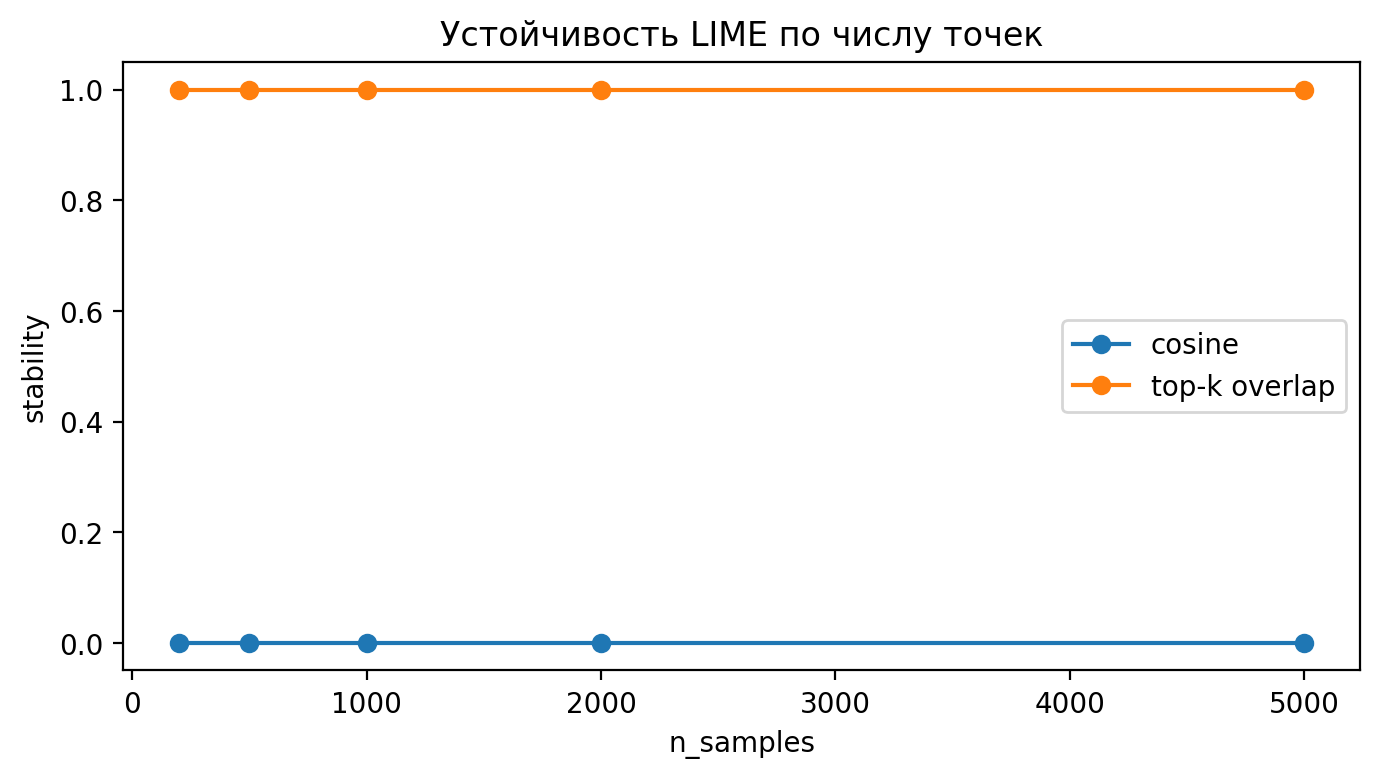

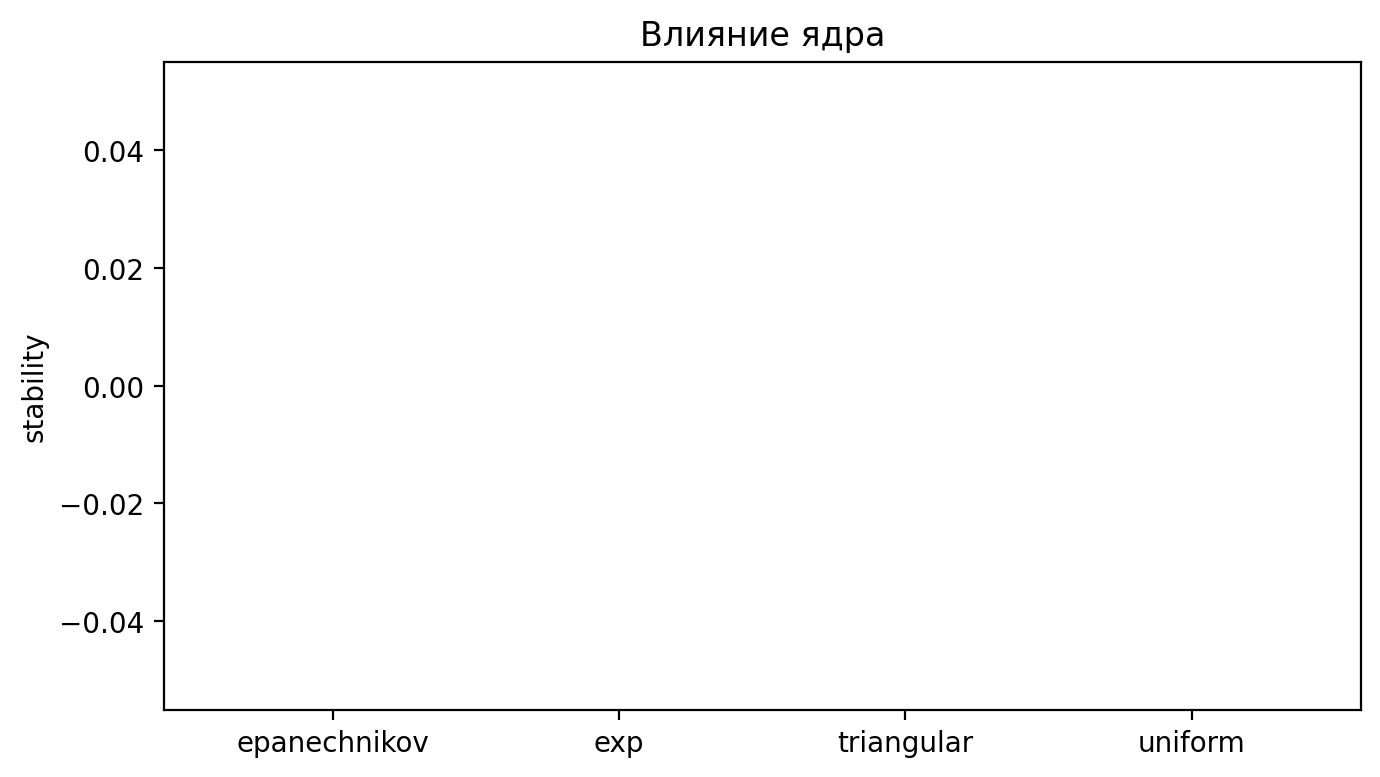

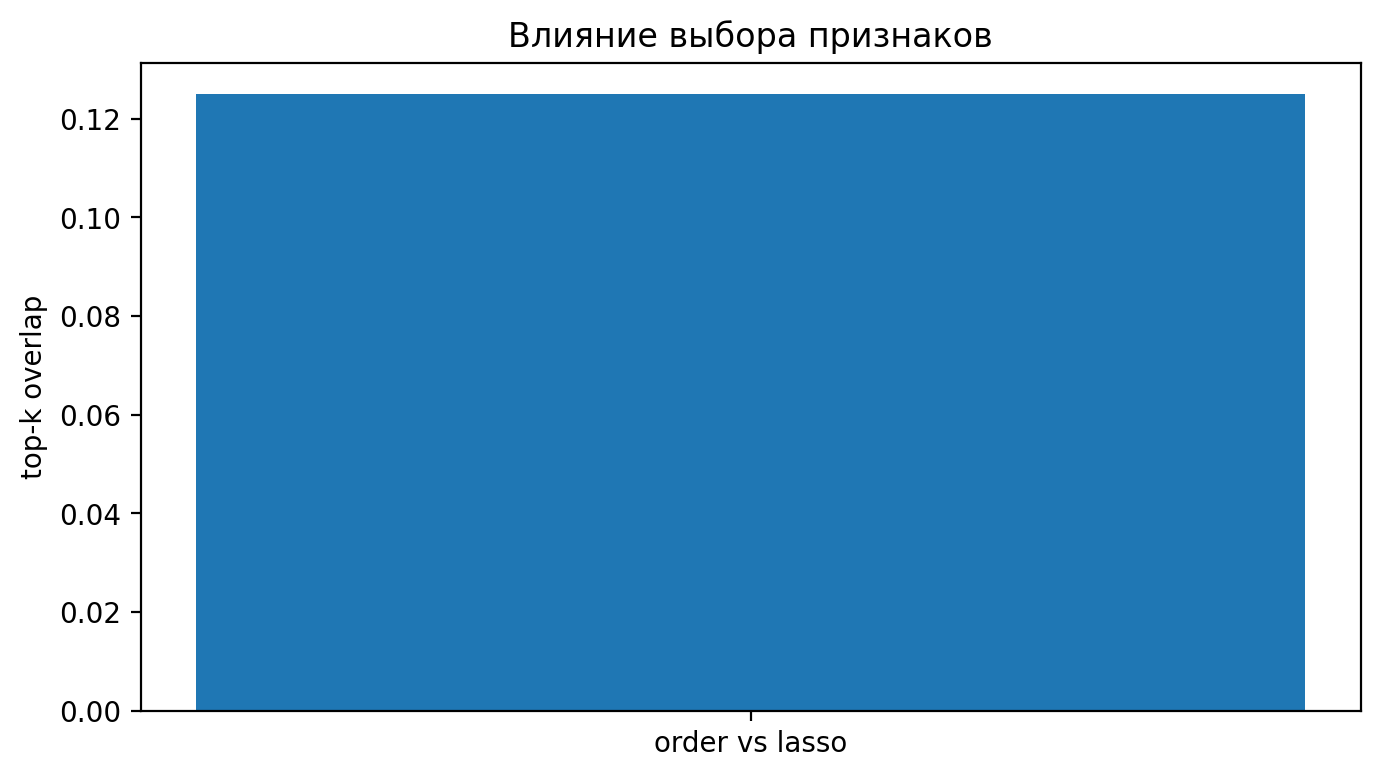

In [14]:
lime_train = X_train_ohe.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float).copy()
lime_test = X_test_ohe.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float).copy()

def exponential_kernel(d, kernel_width=0.75):
    return np.exp(-d / kernel_width)

def uniform_kernel(d, kernel_width=0.75):
    return (d <= kernel_width).astype(float)

def triangular_kernel(d, kernel_width=0.75):
    return np.maximum(1 - d / kernel_width, 0.0)

def epanechnikov_kernel(d, kernel_width=0.75):
    u = d / kernel_width
    return np.where(np.abs(u) <= 1, 1 - u**2, 0.0)

class LIME:
    def __init__(self, train_df, kernel, kernel_width=0.75):
        self.train_df = train_df.copy()
        self.kernel = kernel
        self.kernel_width = kernel_width
        self.feature_names = self.train_df.columns.tolist()
        self.scaler = StandardScaler().fit(self.train_df.values)
        self.stds = self.train_df.std(axis=0).replace(0, 1.0).fillna(1.0).values.astype(float)
        self.low = self.train_df.quantile(0.01).values.astype(float)
        self.high = self.train_df.quantile(0.99).values.astype(float)

    def _sample(self, instance, rng, n_samples):
        mu = instance.values.astype(float)
        samples = rng.normal(loc=mu, scale=self.stds, size=(n_samples, len(mu)))
        samples = np.clip(samples, self.low, self.high)
        return pd.DataFrame(samples, columns=self.feature_names)

    def explain(self, instance, predict_fn, num_features=6, n_samples=2000, alpha=0.1, selection="lasso", seed=42, return_vector=False):
        if not isinstance(instance, pd.Series):
            instance = pd.Series(instance, index=self.train_df.columns)

        instance = instance.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
        instance = instance.clip(pd.Series(self.low, index=self.feature_names), pd.Series(self.high, index=self.feature_names))

        rng = np.random.default_rng(seed)
        samples = self._sample(instance, rng, n_samples)
        samples = samples.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)

        X_scaled = self.scaler.transform(samples.values)
        X_scaled = np.clip(X_scaled, -8, 8)
        x0 = self.scaler.transform(instance.values.reshape(1, -1))
        x0 = np.clip(x0, -8, 8)

        distances = pairwise_distances(X_scaled, x0).ravel()
        weights = self.kernel(distances, self.kernel_width).astype(float)
        weights = np.clip(weights, 1e-8, None)

        y_pred = np.asarray(predict_fn(samples)).ravel().astype(float)
        y_pred = np.nan_to_num(y_pred, nan=np.nanmedian(y_pred), posinf=np.nanmax(y_pred[np.isfinite(y_pred)]) if np.isfinite(y_pred).any() else 0.0, neginf=np.nanmin(y_pred[np.isfinite(y_pred)]) if np.isfinite(y_pred).any() else 0.0)

        if selection == "lasso":
            wsum = weights.sum()
            y_mean = np.average(y_pred, weights=weights) if wsum > 0 else y_pred.mean()
            y_centered = y_pred - y_mean
            y_std = np.sqrt(np.average(y_centered**2, weights=weights)) if wsum > 0 else y_centered.std()
            if not np.isfinite(y_std) or y_std == 0:
                y_std = 1.0
            y_scaled = y_centered / y_std

            sqrtw = np.sqrt(weights)
            Xw = X_scaled * sqrtw[:, None]
            yw = y_scaled * sqrtw
            Xw = np.nan_to_num(Xw, nan=0.0, posinf=1e6, neginf=-1e6)
            yw = np.nan_to_num(yw, nan=0.0, posinf=1e6, neginf=-1e6)

            reg = None
            alpha_try = alpha
            for _ in range(7):
                try:
                    reg = Lasso(alpha=alpha_try, fit_intercept=True, max_iter=100000, tol=1e-4, random_state=seed)
                    reg.fit(Xw, yw)
                    break
                except ValueError:
                    alpha_try *= 10
            if reg is None:
                reg = LinearRegression().fit(Xw, yw)
            coef = np.asarray(reg.coef_, dtype=float) * y_std
            intercept = float(y_mean)
        elif selection in {"order", "forward"}:
            chosen = []
            remaining = list(range(X_scaled.shape[1]))
            k = min(num_features, X_scaled.shape[1])
            for _ in range(k):
                best_j, best_score = None, np.inf
                for j in remaining:
                    cols = chosen + [j]
                    reg = LinearRegression()
                    reg.fit(X_scaled[:, cols], y_pred, sample_weight=weights)
                    pred = reg.predict(X_scaled[:, cols])
                    score = np.average((y_pred - pred) ** 2, weights=weights)
                    if score < best_score:
                        best_score = score
                        best_j = j
                chosen.append(best_j)
                remaining.remove(best_j)
            reg = LinearRegression()
            reg.fit(X_scaled[:, chosen], y_pred, sample_weight=weights)
            coef = np.zeros(X_scaled.shape[1], dtype=float)
            coef[chosen] = reg.coef_.ravel()
            intercept = float(reg.intercept_)
        else:
            raise ValueError("selection must be 'lasso' or 'order'")

        out = pd.DataFrame({"feature": self.feature_names, "coef": coef})
        out = out.reindex(out["coef"].abs().sort_values(ascending=False).index).head(num_features).reset_index(drop=True)

        if return_vector:
            return out, coef, intercept, samples, weights, y_pred
        return out

def compare_vectors(v, ref, k=8):
    v = np.asarray(v).ravel()
    ref = np.asarray(ref).ravel()
    denom = np.linalg.norm(v) * np.linalg.norm(ref)
    cosine = 0.0 if denom == 0 else float(np.dot(v, ref) / denom)
    top_v = set(np.argsort(np.abs(v))[-k:])
    top_ref = set(np.argsort(np.abs(ref))[-k:])
    overlap = len(top_v & top_ref) / k
    return cosine, overlap

kernels = {
    "exp": exponential_kernel,
    "uniform": uniform_kernel,
    "triangular": triangular_kernel,
    "epanechnikov": epanechnikov_kernel,
}

for name, fn in kernels.items():
    vals = fn(np.array([0.0, 0.5, 1.0]), 0.75)
    assert np.all(np.isfinite(vals))
    assert np.all(vals >= 0)

explainer = LIME(lime_train, kernel=epanechnikov_kernel, kernel_width=0.75)

tmp_df, tmp_vec, _, _, _, _ = explainer.explain(lime_test.iloc[0], model.predict, num_features=5, n_samples=300, selection="lasso", return_vector=True)
assert len(tmp_df) == 5
assert np.isfinite(tmp_vec).all()
assert lime_train.isna().sum().sum() == 0
assert lime_test.isna().sum().sum() == 0

example_ids = [0, len(lime_test) // 3, 2 * len(lime_test) // 3]
tables = []

for idx in example_ids:
    instance = lime_test.iloc[idx]
    pred_val = float(model.predict(instance.to_frame().T)[0])
    true_val = float(y_test.iloc[idx])
    exp_df, exp_vec, intercept, _, _, _ = explainer.explain(
        instance,
        model.predict,
        num_features=8,
        n_samples=2500,
        alpha=0.1,
        selection="lasso",
        seed=42,
        return_vector=True
    )
    print(f"\nПример {idx}")
    print("prediction:", round(pred_val, 4), "true:", round(true_val, 4))
    display(exp_df.round(4))
    tables.append(exp_df.assign(example=idx))

display(pd.concat(tables, ignore_index=True).round(4))

sel_idx = example_ids[0]
sel_instance = lime_test.iloc[sel_idx]
lasso_df, lasso_vec, _, _, _, _ = explainer.explain(sel_instance, model.predict, num_features=8, n_samples=2500, selection="lasso", seed=42, return_vector=True)
order_df, order_vec, _, _, _, _ = explainer.explain(sel_instance, model.predict, num_features=8, n_samples=2500, selection="order", seed=42, return_vector=True)

print(f"\nСравнение selection на примере {sel_idx}")
display(pd.concat([lasso_df.assign(selection="lasso"), order_df.assign(selection="order")], ignore_index=True).round(4))

n_grid = [200, 500, 1000, 2000, 5000]
seeds = [0, 1, 2]
num_features = 8

sample_rows = []
kernel_rows = []
selection_rows = []

for idx in example_ids[:2]:
    instance = lime_test.iloc[idx]
    base_vec = explainer.explain(instance, model.predict, num_features=num_features, n_samples=max(n_grid), selection="lasso", seed=0, return_vector=True)[1]

    for n in n_grid:
        vals = []
        for seed in seeds:
            vec = explainer.explain(instance, model.predict, num_features=num_features, n_samples=n, selection="lasso", seed=seed, return_vector=True)[1]
            vals.append(compare_vectors(vec, base_vec, k=num_features))
        sample_rows.append({
            "example": idx,
            "n_samples": n,
            "cosine_mean": np.mean([v[0] for v in vals]),
            "cosine_std": np.std([v[0] for v in vals]),
            "topk_overlap_mean": np.mean([v[1] for v in vals]),
            "topk_overlap_std": np.std([v[1] for v in vals]),
        })

    for kname, kfn in kernels.items():
        vals = []
        for seed in seeds:
            vec = LIME(lime_train, kernel=kfn, kernel_width=0.75).explain(
                instance, model.predict, num_features=num_features, n_samples=2000, selection="lasso", seed=seed, return_vector=True
            )[1]
            vals.append(compare_vectors(vec, base_vec, k=num_features))
        kernel_rows.append({
            "example": idx,
            "kernel": kname,
            "cosine_mean": np.mean([v[0] for v in vals]),
            "topk_overlap_mean": np.mean([v[1] for v in vals]),
        })

    vec_lasso = explainer.explain(instance, model.predict, num_features=num_features, n_samples=2000, selection="lasso", seed=0, return_vector=True)[1]
    vec_order = explainer.explain(instance, model.predict, num_features=num_features, n_samples=2000, selection="order", seed=0, return_vector=True)[1]
    c, o = compare_vectors(vec_order, vec_lasso, k=num_features)
    selection_rows.append({"example": idx, "selection": "order vs lasso", "cosine": c, "topk_overlap": o})

sample_summary = pd.DataFrame(sample_rows).groupby("n_samples", as_index=False)[["cosine_mean", "cosine_std", "topk_overlap_mean", "topk_overlap_std"]].mean()
kernel_summary = pd.DataFrame(kernel_rows).groupby("kernel", as_index=False)[["cosine_mean", "topk_overlap_mean"]].mean()
selection_summary = pd.DataFrame(selection_rows).groupby("selection", as_index=False)[["cosine", "topk_overlap"]].mean()

display(sample_summary.round(4))
display(kernel_summary.round(4))
display(selection_summary.round(4))

plt.figure(figsize=(7, 4))
plt.plot(sample_summary["n_samples"], sample_summary["cosine_mean"], marker="o", label="cosine")
plt.plot(sample_summary["n_samples"], sample_summary["topk_overlap_mean"], marker="o", label="top-k overlap")
plt.xlabel("n_samples")
plt.ylabel("stability")
plt.title("Устойчивость LIME по числу точек")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
x = np.arange(len(kernel_summary))
plt.bar(x, kernel_summary["cosine_mean"])
plt.xticks(x, kernel_summary["kernel"])
plt.ylabel("stability")
plt.title("Влияние ядра")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
x = np.arange(len(selection_summary))
plt.bar(x, selection_summary["topk_overlap"])
plt.xticks(x, selection_summary["selection"])
plt.ylabel("top-k overlap")
plt.title("Влияние выбора признаков")
plt.tight_layout()
plt.show()


## Задание 7. 1 балл. SHAP
Постройте локальный график с SHAP для объекта с индексом, равным вашему номеру в таблице курса на обеих моделях и сделайте выводы. 



ПРИПИСКА. Таблица, которая есть у Вас, её, насколько я посмотреа, в общий чат не кидали, поэтому я вязла наш обычный списко групп, который мы всем преподавателям предоставляем, и взяла свой номер оттуда, учитывая, что 15 группа идёт первая.Вот, я 32

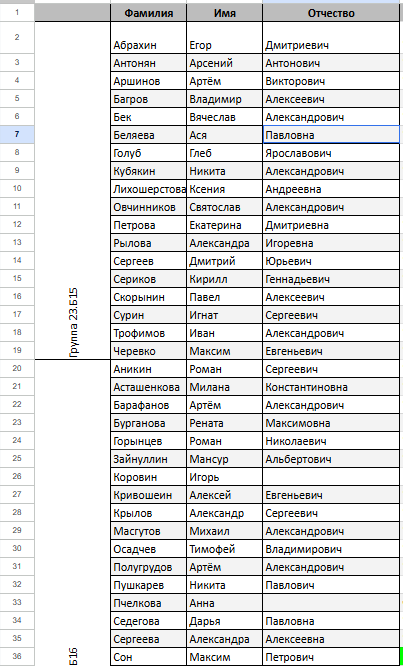

LR 34468.2244


,shap
class_cat,5632.365956
location_university_w_mean_distance,4589.897788
location_public_transport_platform_cnt,-3299.488791
location_parking_cnt,2627.834501
location_residential_cnt,2449.581527
location_leisure_cnt,-1565.997372
location_college_cnt,1544.829786
location_amenity_leisure_w_mean_distance,-1539.533349
location_leisure_w_mean_distance,1445.772259
location_shop_alco_cnt,-1441.632908


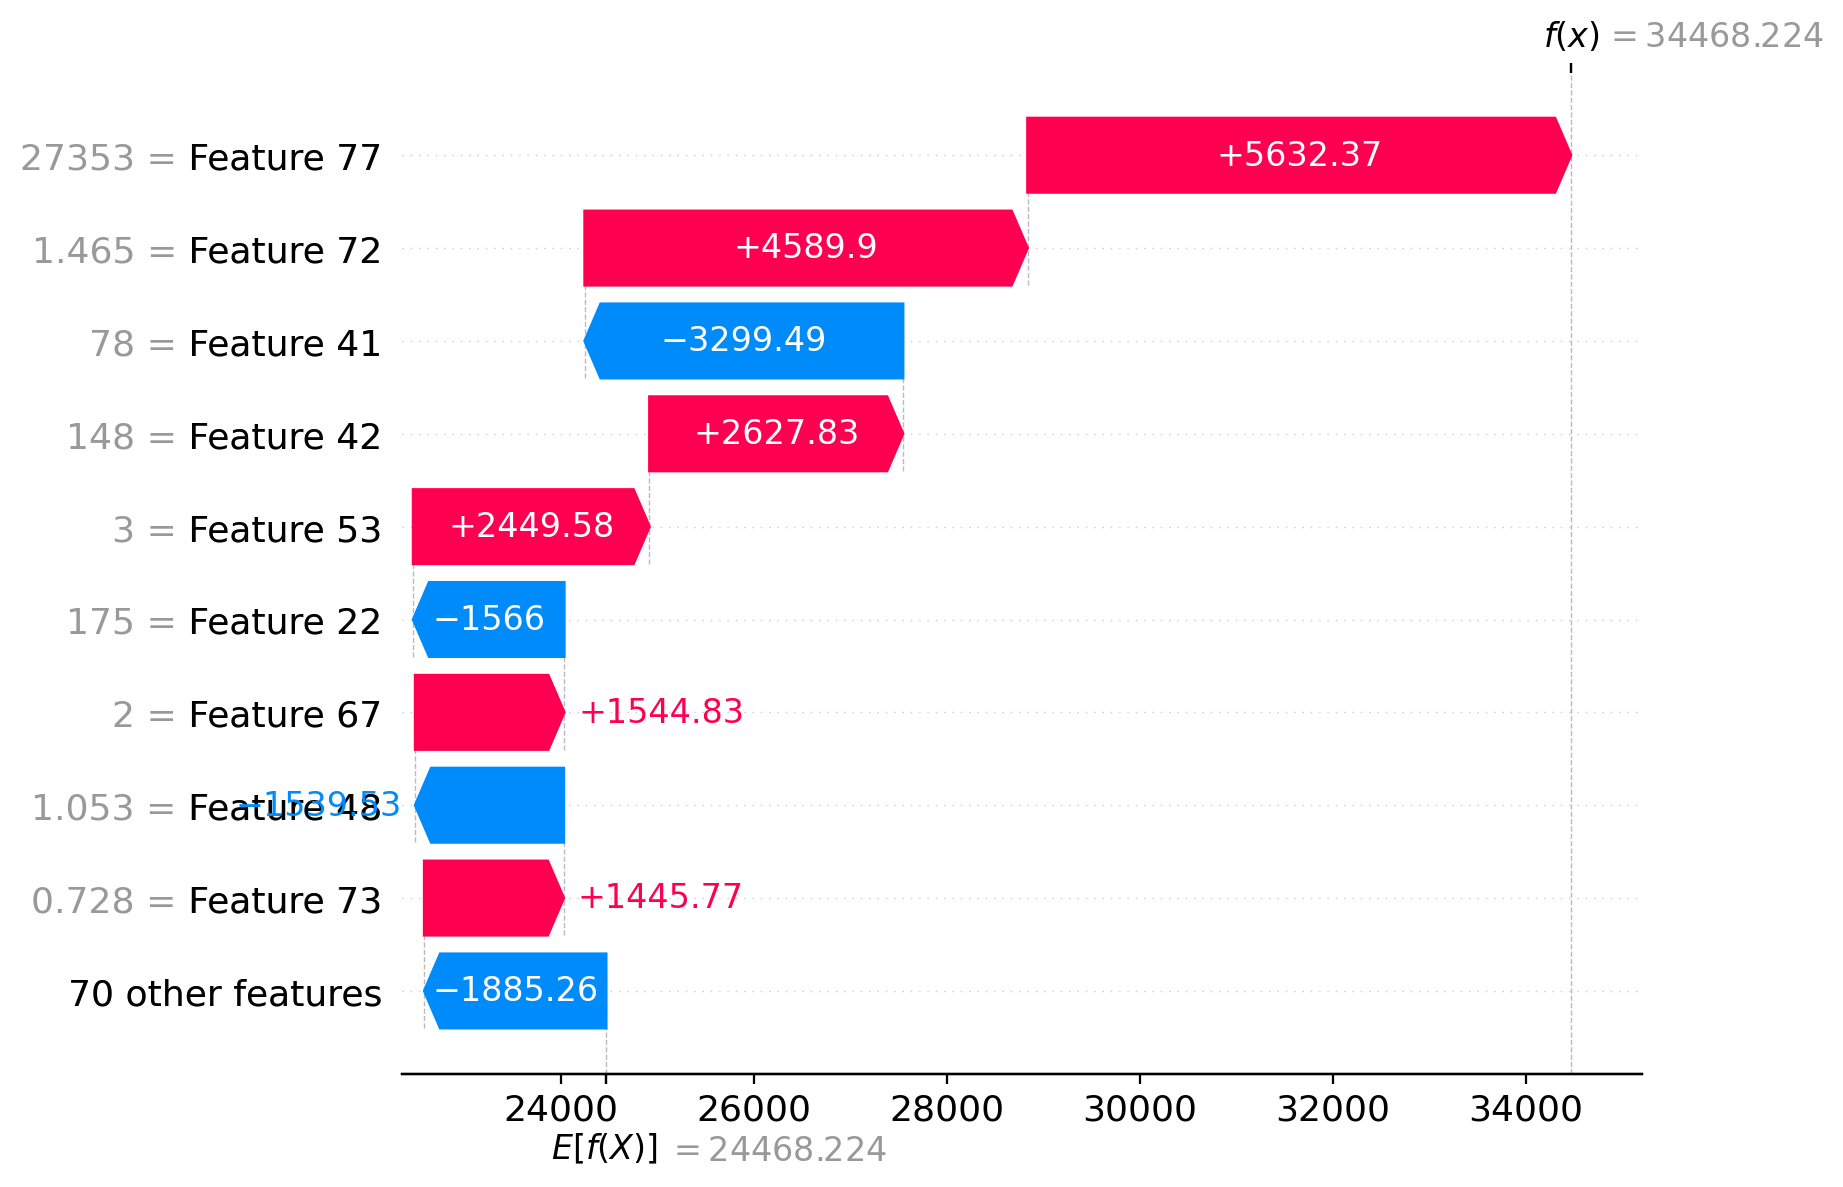

GBR 33947.2608


,shap
class_cat,5772.642840
location_public_transport_stop_position_cnt,1898.293697
location_logs_count_mean,833.360403
interior_cat,650.347631
location_school_w_mean_distance,-599.062174
stage_cat,565.753464
location_fuel_w_mean_distance,-505.847390
location_marketplace_w_mean_distance,-421.651170
location_leisure_w_mean_distance,417.736538
floor,394.282797


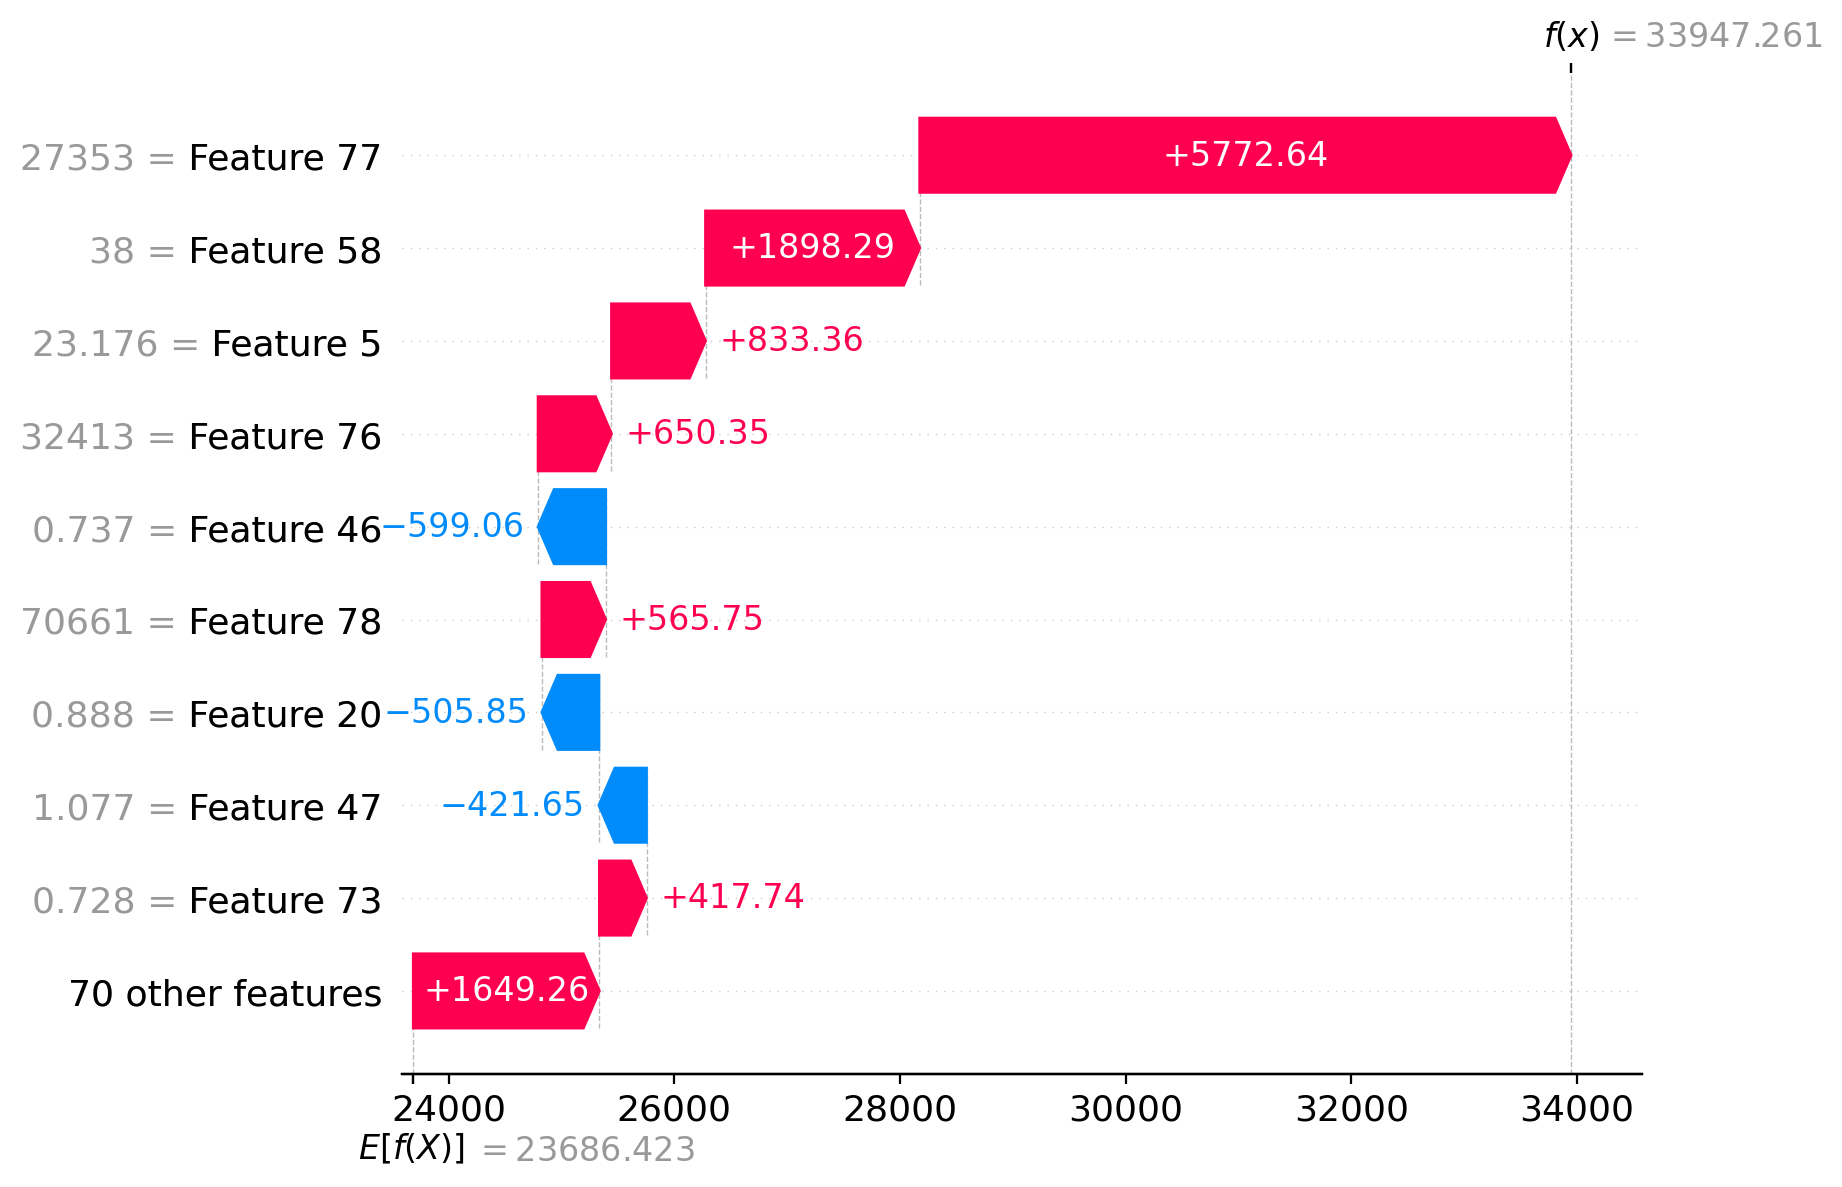

In [15]:
if not hasattr(np, "bool"):
    np.bool = bool

if "X_train_imp" not in globals():
    df = pd.read_csv(data_path)
    df = df.loc[:, ~df.columns.duplicated()]
    y = df["price_target"]
    X = df.drop(columns=["price_target"]).select_dtypes(include=[np.number])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    imputer = SimpleImputer(strategy="median")
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns, index=X_train.index)
    X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns, index=X_test.index)
    lr_lime = LinearRegression().fit(X_train_imp, y_train)
    gbr_lime = GradientBoostingRegressor(max_depth=5, random_state=42).fit(X_train_imp, y_train)

obj_id = 32
x_obj = X.loc[[obj_id], X.columns]
x_obj_imp = imputer.transform(x_obj)

for model, name in [(lr_lime, "LR"), (gbr_lime, "GBR")]:
    bg = X_train_imp.sample(n=min(200, len(X_train_imp)), random_state=42)
    explainer = shap.Explainer(model, bg)
    sv = explainer(x_obj_imp)
    vals = pd.Series(sv.values[0], index=X.columns).sort_values(key=np.abs, ascending=False)
    print(name, round(model.predict(x_obj_imp)[0], 4))
    display(vals.head(15).to_frame("shap"))
    shap.plots.waterfall(sv[0], max_display=10)


## Задание 7.1 (*). 1 балл.  Shap и категориальные переменные.
Shap разлагает предсказание модели вблизи точки x на базовый уровень и сумму вкладов признаков: $ f(x) = base + \sum_i{\phi_i(x)}$. В случае one-hot вклад признака - это сумма вкладов dummy столбцов. Сравните вклады категориальных признаков до и после кодировки - так ли это? 

LR, object 32, prediction = 30953.7780


,category,group_shap,abs_sum,n_dummies
0,district_cat,-5994.559858,10615.254702,68
1,developer_cat,6557.613656,7469.511353,72
2,corpus_cat,-1283.746786,3716.442772,455
3,region_name_cat,1197.214933,1197.214933,2


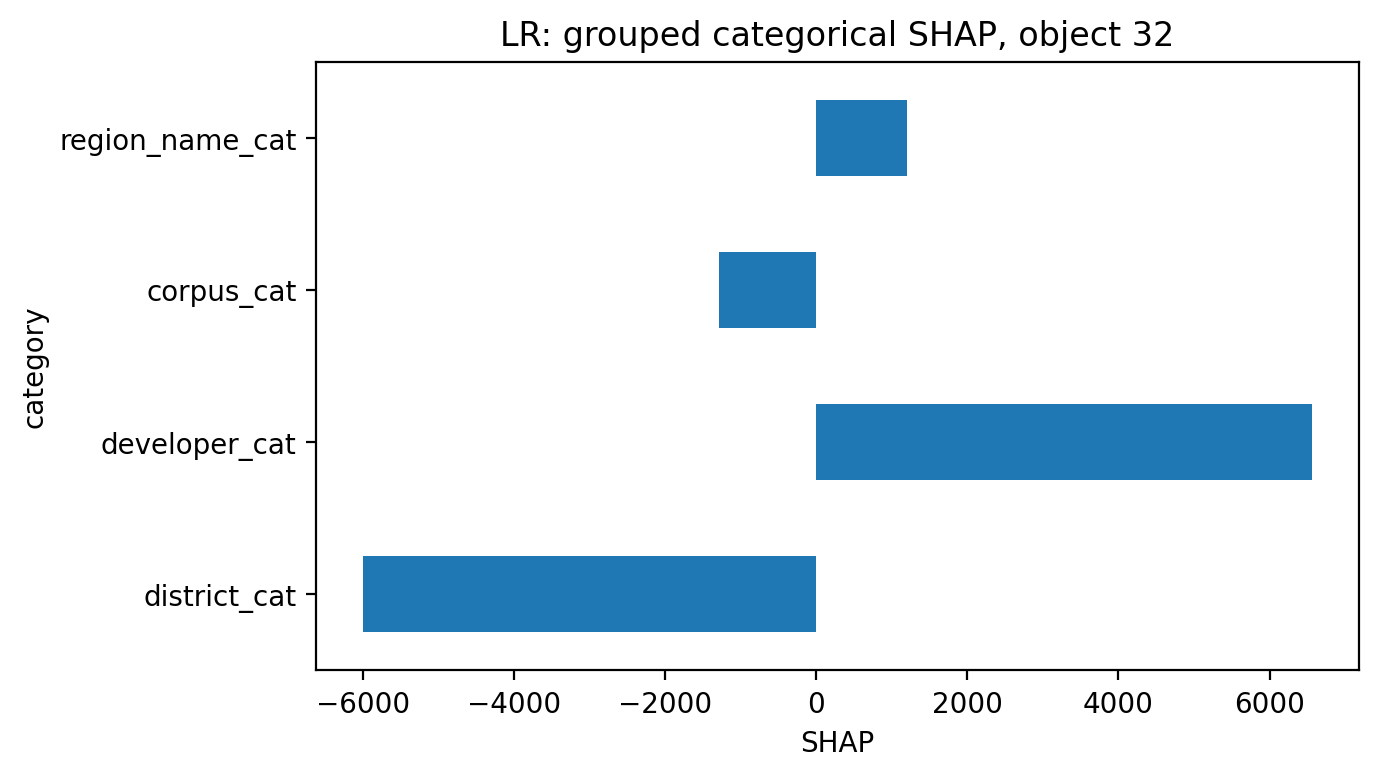

,shap
class_cat,10330.735964
district_cat_71,-7452.181878
developer_cat_99,5351.146864
location_parking_cnt,4646.406474
location_water_cnt,-4093.237294
location_public_transport_platform_cnt,-2628.556442
location_commercial_w_mean_distance,-2023.276285
location_university_w_mean_distance,-1958.030963
corpus_cat_818,-1807.133695
location_leisure_cnt,-1756.226151


GBR, object 32, prediction = 33340.6849


,category,group_shap,abs_sum,n_dummies
0,region_name_cat,129.569815,129.569815,2
1,corpus_cat,-11.785665,98.046455,455
2,district_cat,-32.273322,78.635743,68
3,developer_cat,-10.750364,34.282177,72


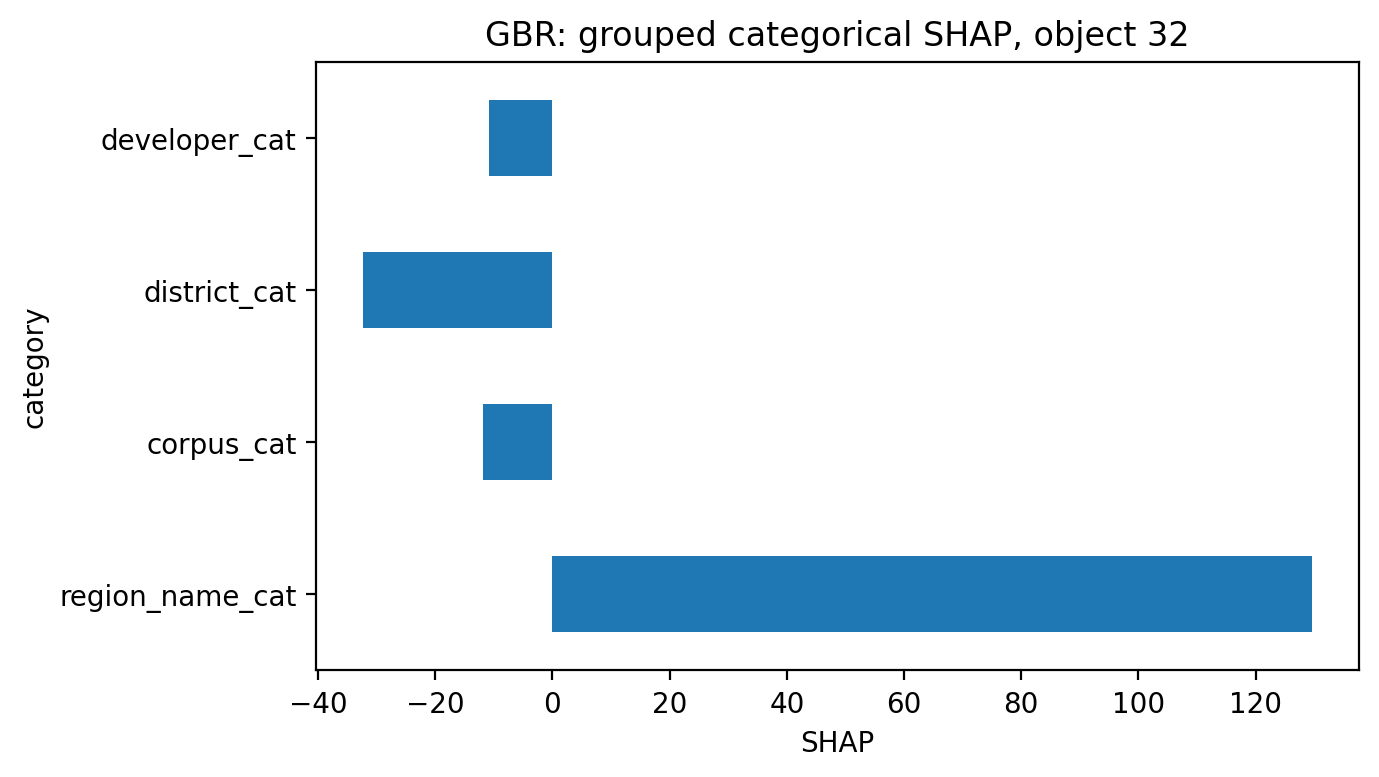

,shap
class_cat,5383.430275
location_public_transport_stop_position_cnt,1843.746073
location_leisure_w_mean_distance,796.423079
location_logs_count_mean,633.762473
location_school_w_mean_distance,-592.035001
interior_cat,577.528298
location_marketplace_w_mean_distance,-526.236723
stage_cat,495.564063
location_fuel_w_mean_distance,-443.940672
floor,381.103967


In [16]:
df2 = df.loc[:, ~df.columns.duplicated()].copy()
target = "price_target"
cat_cols = ["region_name_cat", "district_cat", "corpus_cat", "developer_cat"]
drop_cols = [target, "agreement_date"]
X_cat = df2.drop(columns=drop_cols)
y_cat = df2[target]

for c in X_cat.columns:
    if c not in cat_cols:
        X_cat[c] = pd.to_numeric(X_cat[c], errors="coerce")

num_cols = [c for c in X_cat.columns if c not in cat_cols]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", ohe, cat_cols),
        ("num", SimpleImputer(strategy="median"), num_cols),
    ],
    verbose_feature_names_out=False
)

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42
)

X_train_enc = preprocess.fit_transform(X_train_cat)
X_test_enc = preprocess.transform(X_test_cat)
cat_feature_names = preprocess.named_transformers_["cat"].get_feature_names_out(cat_cols)
feature_names = np.r_[cat_feature_names, num_cols]

X_train_enc_df = pd.DataFrame(X_train_enc, columns=feature_names)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=feature_names)

lr_cat = LinearRegression()
lr_cat.fit(X_train_enc_df, y_train_cat)

gbr_cat = GradientBoostingRegressor(max_depth=5, random_state=42)
gbr_cat.fit(X_train_enc_df, y_train_cat)

x32 = X_cat.loc[[32]]
x32_enc = preprocess.transform(x32)
x32_enc_df = pd.DataFrame(x32_enc, columns=feature_names)

def grouped_category_table(values):
    s = pd.Series(values, index=feature_names)
    rows = []
    for c in cat_cols:
        cols = [n for n in feature_names if n.startswith(c + "_")]
        rows.append({
            "category": c,
            "group_shap": s[cols].sum(),
            "abs_sum": s[cols].abs().sum(),
            "n_dummies": len(cols)
        })
    return pd.DataFrame(rows).sort_values("abs_sum", ascending=False).reset_index(drop=True)

for model, name in [(lr_cat, "LR"), (gbr_cat, "GBR")]:
    bg = X_train_enc_df.sample(n=min(200, len(X_train_enc_df)), random_state=42)
    explainer = shap.Explainer(model, bg)
    sv = explainer(x32_enc_df)
    values = sv.values[0]
    print(f"{name}, object 32, prediction = {model.predict(x32_enc_df)[0]:.4f}")
    cat_tbl = grouped_category_table(values)
    display(cat_tbl)
    cat_tbl.set_index("category")["group_shap"].plot(kind="barh", figsize=(7, 4))
    plt.title(f"{name}: grouped categorical SHAP, object 32")
    plt.xlabel("SHAP")
    plt.tight_layout()
    plt.show()
    full_tbl = pd.Series(values, index=feature_names).sort_values(key=np.abs, ascending=False)
    display(full_tbl.head(15).to_frame("shap"))